# Packages

In [52]:
# Basic Package Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Non-basic package imports
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.nn import CrossEntropyLoss
import requests
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# Packages I don't understand
from fcd_torch import FCD
import rdkit
from collections import Counter
import gc
import pickle
import wandb

# Add the Python_files directory to the Python path
import sys
import os
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'Python_files'))

# Now you can import your modules
import functions_enc as f
import function_depot as fd



# Functions

## 2 Step Encoder Means and Standard Deviation Confusion Matrix Code

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.metrics import confusion_matrix
import os
from glob import glob
def create_percentage_confusion_matrix_mean_std(
        folder, folder_name, bin_size, threshold_size, 
        use_super_test=False, save_plots=True, test_only=True, num_loops=None):
    """
    Compute mean and stddev of percentage confusion matrices over multiple looped output files.
    Will process multiple parquet files matching the base name pattern (before loop number).
    Plots the mean confusion matrix; each cell annotated with "mean ± std".
    Optionally limit the number of loops/files used with num_loops.
    """

    def response_to_tox_class_local(response_value):
        if response_value <= 5:
            return 0
        elif response_value <= 50:
            return 1
        elif response_value <= 500:
            return 2
        elif response_value <= 5000:
            return 3
        else:
            return 4

    # Prepare the file pattern for glob
    folder_path = os.path.join(folder, folder_name)
    bin_part = str(bin_size).replace('.', '_')
    threshold_part = str(threshold_size).replace('.', '_')
    base_fp = (
        f"super_test_cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra"
        if use_super_test else f"cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra"
    )
    file_pattern = os.path.join(folder_path, f"{base_fp}_loop*.parquet")

    file_list = sorted(glob(file_pattern))
    if len(file_list) == 0:
        raise FileNotFoundError(f"No files found matching pattern: {file_pattern}")
    if num_loops is not None:
        file_list = file_list[:num_loops]

    all_cm_percent = []
    n_classes = 5
    class_labels = ["Tox Level 0", "Tox Level 1", "Tox Level 2", "Tox Level 3", "Tox Level 4"]

    for fname in file_list:
        df = pd.read_parquet(fname)
        # Filter to test-only spectra if requested
        if test_only and 'train' in df.columns:
            df = df[df['train'] == 0].copy()
        df['tox_class'] = df['Response'].apply(response_to_tox_class_local)

        y_true = df['tox_class'].values
        y_pred = df['cond_tox_pred_class'].values

        cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))
        # Row-wise normalization (%)
        with np.errstate(divide='ignore', invalid='ignore'):
            cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
            cm_percent = np.nan_to_num(cm_percent)
        all_cm_percent.append(cm_percent)

    all_cm_percent = np.array(all_cm_percent)  # shape (n_files, n_classes, n_classes)
    mean_cm = np.mean(all_cm_percent, axis=0)
    std_cm = np.std(all_cm_percent, axis=0)

    # Plotting
    plt.figure(figsize=(10, 8))
    annot = np.empty_like(mean_cm, dtype=object)
    for i in range(n_classes):
        for j in range(n_classes):
            annot[i, j] = f"{mean_cm[i, j]:.1f}±{std_cm[i, j]:.1f}"

    sns.heatmap(
        mean_cm, annot=annot, fmt='', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        cbar_kws={'label': 'Mean Percentage (%)'},
        square=True
    )

    test_type = "Super Test" if use_super_test else "Regular Test"
    test_label = " (Test Only)" if test_only else ""
    plt.title(f"Confusion Matrix (Mean±Std%) - {test_type}{test_label} (Bin={bin_size}, Threshold={threshold_size})\nn={len(file_list)} loops")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()

    if save_plots:
        save_path = os.path.join(folder_path, f"confusion_matrix_percentages_meanstd_{'super_test_' if use_super_test else ''}bin{bin_size}_thr{threshold_size}_loops.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved as: {save_path}")

    plt.show()

## 2 Step Encoder Confusion Matrix code

In [54]:
def response_to_tox_class(response_value):
    """Convert Response value to tox toxicity class"""
    if response_value <=5:
        return 0  # Tox Level 0
    elif response_value <= 50:
        return 1  # Tox Level 1
    elif response_value <= 500:
        return 2  # Tox Level 2
    elif response_value <= 5000:
        return 3  # Tox Level 3
    else:
        return 4  # Tox Level 4

def load_classification_outputs(base_folder, folder_name, bin_val, threshold_val, use_super_test=False):
    """
    Load classification outputs from the saved folder structure
    """
    # Construct folder path - the outputs are in cond_enc_1234e1e2_classification_df6
    folder_name = folder_name
    folder_path = os.path.join(base_folder, folder_name)
    
    # Convert bin_val and threshold_val to the naming format (replace . with _)
    bin_part = str(bin_val).replace('.', '_')
    threshold_part = str(threshold_val).replace('.', '_')
    
    # Choose file name pattern based on use_super_test parameter
    if use_super_test:
        filename = f"super_test_cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
    else:
        filename = f"cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
    
    outputs_file = os.path.join(folder_path, filename)
    
    if not os.path.exists(outputs_file):
        raise FileNotFoundError(f"Output file not found: {outputs_file}")
    
    df = pd.read_parquet(outputs_file)
    
    # Add tox class from Response values
    df['tox_class'] = df['Response'].apply(response_to_tox_class)
    
    return df

def create_confusion_matrix_plot(y_true, y_pred, class_labels=None, title="Confusion Matrix", save_path=None):
    """
    Create and display a confusion matrix plot
    """
    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Set up class labels
    if class_labels is None:
        class_labels = [f"Class {i}" for i in range(len(np.unique(y_true)))]
    
    # Create the plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', #'RdYlBu_r',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return cm

def analyze_classification_results(base_folder, bin_val, threshold_val, use_super_test=False, save_plots=True):
    """
    Complete analysis function that loads outputs and creates confusion matrices
    """
    # Load the outputs
    try:
        df = load_classification_outputs(base_folder, bin_val, threshold_val, use_super_test)
        test_type = "Super Test" if use_super_test else "Regular Test"
        print(f"Loaded {test_type} outputs for bin={bin_val}, threshold={threshold_val}")
        print(f"Dataset shape: {df.shape}")
    except FileNotFoundError as e:
        print(f"Error: {e}")
        return None, None
    
    # Define tox toxicity class labels
    tox_labels = ["Tox Level 0", "Tox Level 1", "Tox Level 2", "Tox Level 3", "Tox Level 4"]
    
    # Extract true and predicted labels
    y_true = df['tox_class'].values  # tox class derived from Response
    y_pred = df['cond_tox_pred_class'].values  # Predicted class
    
    print(f"Using tox classes derived from Response values")
    
    # Since true labels are 0,1,2,3,4 and predicted are 0,1,2,3,4 we need to adjust
    print(f"True label distribution: {np.bincount(y_true, minlength=5)}")
    print(f"Predicted label distribution: {np.bincount(y_pred, minlength=5)}")
    
    # Old label adjustment - no longer needed
    y_true_adjusted = y_true
    
    # Create confusion matrix
    test_label = "Super Test" if use_super_test else "Regular Test"
    cm = create_confusion_matrix_plot(
        y_true_adjusted, y_pred, 
        class_labels=tox_labels,
        title=f"Confusion Matrix - {test_label} (Bin={bin_val}, Threshold={threshold_val})",
        save_path=f"confusion_matrix_{'super_test_' if use_super_test else ''}bin{bin_val}_thr{threshold_val}.png" if save_plots else None
    )
    
    # Print classification report
    print("\nClassification Report:")
    print(classification_report(y_true_adjusted, y_pred, target_names=tox_labels))
    
    # Calculate and print accuracy metrics
    accuracy = np.sum(y_true_adjusted == y_pred) / len(y_true_adjusted)
    print(f"\nOverall Accuracy: {accuracy:.4f}")
    
    # Per-class accuracy
    print("\nPer-class Accuracy:")
    for i, label in enumerate(tox_labels):
        class_mask = y_true_adjusted == i
        if np.sum(class_mask) > 0:
            class_acc = np.sum((y_true_adjusted == y_pred) & class_mask) / np.sum(class_mask)
            print(f"{label}: {class_acc:.4f}")
    
    return df, cm

def compare_multiple_configurations(base_folder, bin_threshold_pairs, use_super_test=False, save_plots=True):
    """
    Compare results across multiple bin/threshold configurations
    """
    results = {}
    
    for bin_val, threshold_val in bin_threshold_pairs:
        print(f"\n{'='*50}")
        print(f"Analyzing Bin={bin_val}, Threshold={threshold_val}")
        print(f"{'='*50}")
        
        try:
            df, cm = analyze_classification_results(base_folder, bin_val, threshold_val, use_super_test, save_plots)
            if df is not None:
                y_true = df['tox_class'].values  
                y_pred = df['cond_tox_pred_class'].values
                accuracy = np.sum(y_true == y_pred) / len(y_true)
                
                results[(bin_val, threshold_val)] = {
                    'accuracy': accuracy,
                    'confusion_matrix': cm,
                    'dataframe': df
                }
                
        except Exception as e:
            print(f"Error processing bin={bin_val}, threshold={threshold_val}: {e}")
    
    # Summary comparison
    if results:
        print(f"\n{'='*60}")
        print("SUMMARY COMPARISON")
        print(f"{'='*60}")
        print(f"{'Bin':<8} {'Threshold':<12} {'Accuracy':<10}")
        print("-" * 30)
        
        for (bin_val, threshold_val), metrics in results.items():
            print(f"{bin_val:<8} {threshold_val:<12} {metrics['accuracy']:.4f}")
    
    return results

def visualize_classification(folder, bin_size, threshold_size, use_super_test=False, save_plots=True):
    """
    Main visualization function that takes folder, bin size, and threshold size
    
    Parameters:
    folder (str): Base folder path containing the classification outputs
    bin_size (int/float): Bin size value
    threshold_size (float): Threshold size value  
    use_super_test (bool): Whether to load super test results or regular test results
    save_plots (bool): Whether to save plots as PNG files
    
    Returns:
    tuple: DataFrame and confusion matrix from the analysis
    """
    test_type = "Super Test" if use_super_test else "Regular Test"
    print(f"Analyzing {test_type} classification results:")
    print(f"Folder: {folder}")
    print(f"Bin size: {bin_size}")
    print(f"Threshold size: {threshold_size}")
    print("-" * 50)
    
    # Run the analysis
    df, cm = analyze_classification_results(folder, bin_size, threshold_size, use_super_test, save_plots)
    
    return df, cm



# Create percentage-based confusion matrix heatmap
def create_percentage_confusion_matrix_standalone(folder, folder_name, bin_size, threshold_size, use_super_test=False, save_plots=True, test_only=True):
    """
    Standalone function to create percentage confusion matrix from classification outputs
    Each row shows how the actual label was distributed across predictions
    
    Parameters:
    test_only (bool): If True, only include test/validation spectra (exclude training spectra where train=1)
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import confusion_matrix
    import os
    
    def response_to_tox_class_local(response_value):
        """Convert Response value to Tox toxicity class"""
        if response_value <= 5:
            return 0  # Tox Level 0
        elif response_value <= 50:
            return 1  # Tox Level 1
        elif response_value <= 500:
            return 2  # Tox Level 2
        elif response_value <= 5000:
            return 3  # Tox Level 3
        else:
            return 4  # Tox Level 4
    
    # Load the classification outputs
    folder_name = folder_name
    folder_path = os.path.join(folder, folder_name)
    
    # Convert bin_size and threshold_size to the naming format (replace . with _)
    bin_part = str(bin_size).replace('.', '_')
    threshold_part = str(threshold_size).replace('.', '_')
    
    # Choose file name pattern based on use_super_test parameter
    if use_super_test:
        filename = f"super_test_cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
    else:
        filename = f"cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
    
    outputs_file = os.path.join(folder_path, filename)
    
    if not os.path.exists(outputs_file):
        raise FileNotFoundError(f"Output file not found: {outputs_file}")
    
    df = pd.read_parquet(outputs_file)
    
    # Filter to test-only spectra if requested
    if test_only:
        if 'train' in df.columns:
            original_count = len(df)
            df = df[df['train'] == 0].copy()
            filtered_count = len(df)
            print(f"Filtered to test-only spectra: {filtered_count}/{original_count} samples ({filtered_count/original_count*100:.1f}%)")
        else:
            print("Warning: 'train' column not found, cannot filter to test-only spectra")
    
    # Add Tox class from Response values
    df['tox_class'] = df['Response'].apply(response_to_tox_class_local)
    
    # Extract and adjust labels
    y_true = df['tox_class'].values   
    y_pred = df['cond_tox_pred_class'].values
    
    # Define Tox labels
    class_labels = ["Tox Level 0", "Tox Level 1", "Tox Level 2", "Tox Level 3", "Tox Level 4"]
    
    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3, 4])
    
    # Convert to percentages (row-wise normalization)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Create the plot
    plt.figure(figsize=(10, 8))
    
    # Create heatmap with percentage values
    sns.heatmap(cm_percent, 
                annot=True, 
                fmt='.1f', 
                cmap='Blues', # 'RdYlBu_r'
                xticklabels=class_labels, 
                yticklabels=class_labels,
                cbar_kws={'label': 'Percentage (%)'},
                square=True)
    
    test_type = "Super Test" if use_super_test else "Regular Test"
    test_label = " (Test Only)" if test_only else ""
    plt.title(f"Confusion Matrix - {test_type} Percentages{test_label} (Bin={bin_size}, Threshold={threshold_size})")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    
    if save_plots:
        save_path = f"confusion_matrix_percentages_{'super_test_' if use_super_test else ''}bin{bin_size}_thr{threshold_size}.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved as: {save_path}")
    
    plt.show()
    
    # Print percentage breakdown with proportions
    print(f"\nPercentage breakdown by actual label (Bin={bin_size}, Threshold={threshold_size}):")
    for i, actual_label in enumerate(class_labels):
        row_total = cm.sum(axis=1)[i]
        print(f"\n{actual_label} (Total: {row_total} samples):")
        for j, pred_label in enumerate(class_labels):
            count = cm[i, j]
            percentage = cm_percent[i, j]
            print(f"  → {pred_label}: {percentage:.1f}% ({count}/{row_total} samples)")
    
    return cm_percent, df

## Mean and Standard Deviation Confusion Matrix

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os
from glob import glob

def create_confusion_matrix_general_mean_std(
    folder_path,
    bin_val,
    threshold_val,
    pred_class_col='cond_tox_pred_class',
    response_col='Response',
    train_col='train',
    file_prefix='cond_enc',
    use_super_test=False,
    test_only=True,
    save_plots=False,
    figsize=(10, 8),
    num_loops=None  # New argument to limit number of loops/files
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import confusion_matrix
    import os
    from glob import glob

    bin_part = str(bin_val).replace('.', '_')
    threshold_part = str(threshold_val).replace('.', '_')
    if use_super_test:
        base_fp = f"super_test_{file_prefix}_bin{bin_part}_thresh{threshold_part}_df_spectra"
    else:
        base_fp = f"{file_prefix}_bin{bin_part}_thresh{threshold_part}_df_spectra"
    file_pattern = os.path.join(folder_path, f"{base_fp}_loop*.parquet")
    file_list = sorted(glob(file_pattern))
    if not file_list:
        raise FileNotFoundError(f"No files found matching pattern: {file_pattern}")
    if num_loops is not None:
        file_list = file_list[:num_loops]
    n_classes = 5
    class_labels = ["Tox Level 0", "Tox Level 1", "Tox Level 2", "Tox Level 3", "Tox Level 4"]

    all_cm_percent = []

    for fname in file_list:
        df = pd.read_parquet(fname)
        if test_only and train_col in df.columns:
            df = df[df[train_col] == 0].copy()
        def response_to_tox_class(response_value):
            if response_value <= 5:
                return 0
            elif response_value <= 50:
                return 1
            elif response_value <= 500:
                return 2
            elif response_value <= 5000:
                return 3
            else:
                return 4
        df['tox_class'] = df[response_col].apply(response_to_tox_class)
        y_true = df['tox_class'].values
        y_pred = df[pred_class_col].values
        cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))
        with np.errstate(divide='ignore', invalid='ignore'):
            cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
            cm_percent = np.nan_to_num(cm_percent)
        all_cm_percent.append(cm_percent)

    all_cm_percent = np.array(all_cm_percent)
    mean_cm = np.mean(all_cm_percent, axis=0)
    std_cm = np.std(all_cm_percent, axis=0)

    plt.figure(figsize=figsize)
    annot = np.empty_like(mean_cm, dtype=object)
    for i in range(n_classes):
        for j in range(n_classes):
            annot[i, j] = f"{mean_cm[i, j]:.1f}±{std_cm[i, j]:.1f}"

    sns.heatmap(
        mean_cm, annot=annot, fmt='', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        cbar_kws={'label': 'Mean Percentage (%)'},
        square=True
    )

    test_type = "Super Test" if use_super_test else "Regular Test"
    test_label = " (Test Only)" if test_only else ""
    plt.title(f"Confusion Matrix (Mean±Std%) - {test_type}{test_label}\n(Bin={bin_val}, Threshold={threshold_val})\nn={len(file_list)} loops")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()

    if save_plots:
        save_path = os.path.join(folder_path, f"confusion_matrix_percentages_meanstd_{'super_test_' if use_super_test else ''}bin{bin_val}_thr{threshold_val}_loops.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved as: {save_path}")

    plt.show()

## Confusion Matricies 

In [56]:
def response_to_tox_class(response_value):
    """Convert Response value to Tox toxicity class"""
    if response_value <= 5:
        return 0  # Tox Level 0
    elif response_value <= 50:
        return 1  # Tox Level 1
    elif response_value <= 500:
        return 2  # Tox Level 2
    elif response_value <= 5000:
        return 3  # Tox Level 3
    else:
        return 4  # Tox Level 4

# ==================== FUNCTION 1: CONFUSION MATRIX ==================== #
def create_confusion_matrix_general(
    folder_path,
    bin_val,
    threshold_val,
    pred_class_col='cond_tox_pred_class',
    response_col='Response',
    train_col='train',
    file_prefix='cond_enc',
    use_super_test=False,
    test_only=True,
    save_plots=False,
    figsize=(10, 8)
):
    """
    Create confusion matrix from classification outputs with flexible column names
    
    Parameters:
    -----------
    folder_path : str
        Path to folder containing classification result files
    bin_val : float
        Bin size value
    threshold_val : float
        Threshold value
    pred_class_col : str
        Name of column containing predicted toxicity class (default: 'cond_tox_pred_class')
    response_col : str
        Name of column containing response values (default: 'Response')
    train_col : str
        Name of column indicating training samples (default: 'train')
    file_prefix : str
        Prefix for filenames (default: 'cond_enc')
    use_super_test : bool
        Whether to load super test results
    test_only : bool
        If True, only include test/validation spectra (exclude train==1)
    save_plots : bool
        Whether to save plots as PNG files
    figsize : tuple
        Figure size
    
    Returns:
    --------
    tuple : (confusion_matrix_percentages, dataframe)
    """
    
    # Construct file path
    bin_part = str(bin_val).replace('.', '_')
    threshold_part = str(threshold_val).replace('.', '_')
    
    if use_super_test:
        filename = f"super_test_{file_prefix}_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
    else:
        filename = f"{file_prefix}_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
    
    file_path = os.path.join(folder_path, filename)
    
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Output file not found: {file_path}")
    
    # Load data
    df = pd.read_parquet(file_path)
    
    # Filter to test-only spectra if requested
    if test_only and train_col in df.columns:
        original_count = len(df)
        df = df[df[train_col] == 0].copy()
        filtered_count = len(df)
        print(f"Filtered to test-only spectra: {filtered_count}/{original_count} samples ({filtered_count/original_count*100:.1f}%)")
    
    # Add tox class from Response values
    df['tox_class'] = df[response_col].apply(response_to_tox_class)
    
    # Extract and adjust labels
    y_true = df['tox_class'].values  
    y_pred = df[pred_class_col].values
    
    # Define tox labels
    class_labels = ["Tox Level 0", "Tox Level 1", "Tox Level 2", "Tox Level 3", "Tox Level 4"]
    
    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3, 4])
    
    # Convert to percentages (row-wise normalization)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Create the plot
    plt.figure(figsize=figsize)
    
    # Create heatmap with percentage values
    sns.heatmap(cm_percent, 
                annot=True, 
                fmt='.1f', 
                cmap='Blues', # 'RdYlBu_r', 
                xticklabels=class_labels, 
                yticklabels=class_labels,
                cbar_kws={'label': 'Percentage (%)'},
                square=True)
    
    test_type = "Super Test" if use_super_test else "Regular Test"
    test_label = " (Test Only)" if test_only else ""
    plt.title(f"Confusion Matrix - {test_type} Percentages{test_label}\n(Bin={bin_val}, Threshold={threshold_val})")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    
    if save_plots:
        save_path = f"confusion_matrix_percentages_{'super_test_' if use_super_test else ''}bin{bin_val}_thr{threshold_val}.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved as: {save_path}")
    
    plt.show()
    
    # Print percentage breakdown
    print(f"\nPercentage breakdown by actual label (Bin={bin_val}, Threshold={threshold_val}):")
    for i, actual_label in enumerate(class_labels):
        row_total = cm.sum(axis=1)[i]
        print(f"\n{actual_label} (Total: {row_total} samples):")
        for j, pred_label in enumerate(class_labels):
            count = cm[i, j]
            percentage = cm_percent[i, j]
            print(f"  → {pred_label}: {percentage:.1f}% ({count}/{row_total} samples)")
    
    # Print classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_labels))
    
    return cm_percent, df

## Direct Tox and General Heatmap

In [57]:
# Accuracy heatmap for direct tox classification

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

def calculate_class_accuracy(y_true, y_pred, target_class):
    """Calculate accuracy for a specific class, where class labels are 0-based."""
    class_mask = y_true == target_class
    if np.sum(class_mask) == 0:
        return np.nan  # No samples of this class
    correct_for_class = np.sum((y_true == y_pred) & class_mask)
    total_for_class = np.sum(class_mask)
    return correct_for_class / total_for_class

def parse_direct_tox_filename(filename, use_super_test=False):
    """
    Extract bin size and threshold from direct tox filename,
    supporting an optional 'super_test_' prefix.
    """
    file_prefix = "direct_tox"
    if use_super_test and filename.startswith('super_test_'):
        name_part = filename.replace(f'super_test_{file_prefix}_', '')
    else:
        name_part = filename.replace(f'{file_prefix}_', '')

    if 'thresh_zero' in name_part:
        bin_part = name_part.split('_thresh_zero')[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        threshold = 0.0
    else:
        parts = name_part.split('_thresh')
        bin_part = parts[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        thresh_part = parts[1].split('_df_spectra')[0]
        threshold = float(thresh_part.replace('_', '.'))
    return bin_size, threshold

def load_and_process_direct_tox_classification_data(
    folder_path,
    use_super_test=False,
    test_only=True):
    """
    Load and process direct tox classification data from the specified folder.

    Parameters:
        folder_path (str): Path to folder containing .parquet result files
        use_super_test (bool): If True, filters for 'super_test_' files
        test_only (bool): If True, keep only test/validation spectra (train==0)
    Returns:
        pd.DataFrame with rows for each result file and class accuracy metrics.
    """

    if not os.path.exists(folder_path):
        print(f"Error: Folder {folder_path} does not exist!")
        return pd.DataFrame()

    parquet_files = [f for f in os.listdir(folder_path) if f.endswith('.parquet')]

    # Filter files: only "super_test_" or only "direct_tox_" as needed
    if use_super_test:
        parquet_files = [f for f in parquet_files if f.startswith('super_test_')]
    else:
        parquet_files = [f for f in parquet_files if f.startswith('direct_tox_') and not f.startswith('super_test_')]

    if not parquet_files:
        print(f"No {'super_test_' if use_super_test else 'direct_tox_'} .parquet files found in {folder_path}")
        return pd.DataFrame()

    classification_results = []

    for file in sorted(parquet_files):
        dataset_name = file.replace('.parquet','')
        file_path = os.path.join(folder_path, file)
        try:
            df = pd.read_parquet(file_path)
            if test_only and 'train' in df.columns:
                df = df[df['train'] == 0].copy()
            required_cols = ['direct_tox_pred_class', 'true_tox_class']
            if not all(col in df.columns for col in required_cols):
                print(f"  Warning: Required columns missing in {file}; skipping.")
                continue
            y_pred_class = df['direct_tox_pred_class']
            y_true_class = df['true_tox_class']
            # Remove NaNs
            valid_mask = ~(y_pred_class.isna() | y_true_class.isna())
            y_pred_class_clean = y_pred_class[valid_mask]
            y_true_class_clean = y_true_class[valid_mask]
            if len(y_pred_class_clean) < 10:
                continue
            # Calculate accuracy metrics (four classes: 0,1,2,3)
            overall_accuracy = accuracy_score(y_true_class_clean, y_pred_class_clean)
            class_accs = [
                calculate_class_accuracy(y_true_class_clean, y_pred_class_clean, 0),
                calculate_class_accuracy(y_true_class_clean, y_pred_class_clean, 1),
                calculate_class_accuracy(y_true_class_clean, y_pred_class_clean, 2),
                calculate_class_accuracy(y_true_class_clean, y_pred_class_clean, 3),
            ]
            bin_size, threshold = parse_direct_tox_filename(dataset_name, use_super_test)
            classification_results.append({
                'Dataset': dataset_name,
                'Overall_Accuracy': overall_accuracy,
                'Class0_Accuracy': class_accs[0],
                'Class1_Accuracy': class_accs[1],
                'Class2_Accuracy': class_accs[2],
                'Class3_Accuracy': class_accs[3],
                'Samples': len(y_pred_class_clean),
                'BinSize': bin_size,
                'Threshold': threshold
            })
        except Exception as e:
            print(f"  Error processing {file}: {str(e)}")
            continue

    results_df = pd.DataFrame(classification_results)
    if not results_df.empty:
        results_df = results_df.drop_duplicates(subset=['BinSize','Threshold'], keep='first')
    return results_df

def create_accuracy_heatmap_for_direct_tox(
    folder_path,
    metric='average', # can be 'average', '0', '1', '2', '3'
    colormap='RdYlBu_r', #RdYlGn',
    figsize=(12,8),
    use_super_test=False,
    test_only=True,
    bin_values=None,
    threshold_values=None
):
    """
    Create a heatmap for Classification Accuracy with support for direct tox classifier result files.

    Parameters:
        folder_path (str): Path to folder containing .parquet result files
        metric (str):
            - 'average': Overall accuracy
            - '0', '1', '2', '3', '4': Per-class accuracy (0 = tox1, 1 = tox2, etc)
        colormap (str): color scheme for the heatmap
        figsize (tuple): Figure size
        use_super_test (bool): If True, only use files with 'super_test_' prefix
        test_only (bool): If True, only include test/validation spectra
        bin_values (list or None): Custom list of bin sizes for heatmap Y axis
        threshold_values (list or None): Custom list of threshold values for heatmap X axis
    Returns:
        None
    """
    df_results = load_and_process_direct_tox_classification_data(
        folder_path,
        use_super_test=use_super_test,
        test_only=test_only
    )
    if df_results.empty:
        print("No data for heatmap!")
        return None

    metric_mapping = {
        'average': ('Overall_Accuracy', 'Overall Accuracy'),
        '0': ('Class0_Accuracy', 'Tox Level 0 Accuracy'),
        '1': ('Class1_Accuracy', 'Tox Level 1 Accuracy'),
        '2': ('Class2_Accuracy', 'Tox Level 2 Accuracy'),
        '3': ('Class3_Accuracy', 'Tox Level 3 Accuracy'),
        '4': ('Class4_Accuracy', 'Tox Level 4 Accuracy'),
    }
    if metric not in metric_mapping:
        raise ValueError(f"metric must be one of: {list(metric_mapping.keys())}")
    column_name, display_name = metric_mapping[metric]

    # Allow user to provide bin/threshold lists
    if threshold_values is None:
        threshold_values = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
    if bin_values is None:
        bin_values = [0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500]

    accuracy_pivot = df_results.pivot(index='BinSize', columns='Threshold', values=column_name)
    accuracy_pivot = accuracy_pivot.reindex(columns=threshold_values, index=bin_values)

    plt.figure(figsize=figsize)
    ax = sns.heatmap(
        accuracy_pivot,
        annot=True,
        fmt='.3f',
        cmap=colormap,
        square=False,
        linewidths=0.5,
        vmin=0, vmax=1,
        cbar_kws={'label': display_name, 'shrink': 0.8}
    )
    test_label = " (Test Only)" if test_only else ""
    test_type = "Super Test" if use_super_test else "Regular Test"
    plt.title(f'Direct Tox Classification ({test_type}): {display_name}{test_label} by Bin Size and Threshold', fontsize=16, fontweight='bold')
    plt.xlabel('Threshold Value', fontsize=14)
    plt.ylabel('Bin Size', fontsize=14)
    plt.gca().invert_yaxis()
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    best_acc = accuracy_pivot.max().max()
    plt.text(
        0.02, 0.98, f'Best {display_name}: {best_acc:.3f}',
        transform=plt.gca().transAxes,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
        verticalalignment='top'
    )
    plt.tight_layout()
    plt.show()
    # No return, just show plot!
    return None

In [58]:
# ==================== FUNCTION 2: General ACCURACY HEATMAP ==================== #
def create_accuracy_heatmap_general(
    folder_path,
    file_prefix='cond_enc',
    pred_class_col='cond_tox_pred_class',
    response_col='Response',
    train_col='train',
    metric='average',
    colormap='RdYlBu_r', #'RdYlGn',
    figsize=(12, 8),
    use_super_test=False,
    test_only=True
):
    """
    Create accuracy heatmap across multiple bin sizes and thresholds
    
    Parameters:
    -----------
    folder_path : str
        Path to folder containing classification result files
    file_prefix : str
        Prefix for filenames (default: 'cond_enc')
    pred_class_col : str
        Name of column containing predicted toxicity class
    response_col : str
        Name of column containing response values
    train_col : str
        Name of column indicating training samples
    metric : str
        Type of accuracy to plot: 'average', '0', '1', '2', '3', '4' for tox levels
    colormap : str
        Color scheme for the heatmap
    figsize : tuple
        Figure size
    use_super_test : bool
        Whether to load super test datasets
    test_only : bool
        If True, only include test/validation spectra
    
    Returns:
    --------
    pandas.DataFrame : Pivot table with accuracy data
    """
    
    def calculate_class_accuracy(y_true, y_pred, target_class):
        """Calculate accuracy for a specific class"""
        target_class_idx = target_class
        class_mask = y_true == target_class_idx
        
        if np.sum(class_mask) == 0:
            return np.nan
        
        correct_for_class = np.sum((y_true == y_pred) & class_mask)
        total_for_class = np.sum(class_mask)
        
        return correct_for_class / total_for_class
    
    def parse_filename(filename, use_super_test):
        """Extract bin size and threshold from filename"""
        if use_super_test and filename.startswith('super_test_'):
            name_part = filename.replace(f'super_test_{file_prefix}_', '')
        else:
            name_part = filename.replace(f'{file_prefix}_', '')
        
        if 'thresh_zero' in name_part:
            bin_part = name_part.split('_thresh_zero')[0].replace('bin', '')
            bin_size = float(bin_part.replace('_', '.'))
            threshold = 0.0
        else:
            parts = name_part.split('_thresh')
            bin_part = parts[0].replace('bin', '')
            bin_size = float(bin_part.replace('_', '.'))
            
            thresh_part = parts[1].split('_df_spectra')[0]
            threshold = float(thresh_part.replace('_', '.'))
        
        return bin_size, threshold
    
    # Check if folder exists
    if not os.path.exists(folder_path):
        print(f"Error: Folder {folder_path} does not exist!")
        return None
    
    # Get all .parquet files
    parquet_files = [f for f in os.listdir(folder_path) if f.endswith('.parquet')]
    
    # Filter files based on test type
    if use_super_test:
        dataset_files = [f for f in parquet_files if f.startswith('super_test_')]
    else:
        dataset_files = [f for f in parquet_files if f.startswith(file_prefix) and not f.startswith('super_test_')]
    
    if not dataset_files:
        test_type = "super test" if use_super_test else "regular"
        print(f"Warning: No {test_type} .parquet files found in {folder_path}")
        return None
    
    # Process each file
    results = []
    
    for filename in sorted(dataset_files):
        try:
            file_path = os.path.join(folder_path, filename)
            df = pd.read_parquet(file_path)
            
            # Filter to test-only if requested
            if test_only and train_col in df.columns:
                df = df[df[train_col] == 0].copy()
            
            # Check required columns
            if pred_class_col not in df.columns or response_col not in df.columns:
                continue
            
            # Get predictions and true values
            y_pred = df[pred_class_col].values
            y_true = df[response_col].apply(response_to_tox_class).values  
            
            # Remove NaN values
            valid_mask = ~(pd.isna(y_pred) | pd.isna(y_true))
            y_pred_clean = y_pred[valid_mask]
            y_true_clean = y_true[valid_mask]
            
            if len(y_pred_clean) < 10:
                continue
            
            # Calculate metrics
            overall_accuracy = accuracy_score(y_true_clean, y_pred_clean)
            class0_accuracy = calculate_class_accuracy(y_true_clean, y_pred_clean, 0)
            class1_accuracy = calculate_class_accuracy(y_true_clean, y_pred_clean, 1)
            class2_accuracy = calculate_class_accuracy(y_true_clean, y_pred_clean, 2)
            class3_accuracy = calculate_class_accuracy(y_true_clean, y_pred_clean, 3)
            class4_accuracy = calculate_class_accuracy(y_true_clean, y_pred_clean, 4)
            
            # Parse filename
            bin_size, threshold = parse_filename(filename, use_super_test)
            
            results.append({
                'BinSize': bin_size,
                'Threshold': threshold,
                'Overall_Accuracy': overall_accuracy,
                'Class1_Accuracy': class1_accuracy,
                'Class2_Accuracy': class2_accuracy,
                'Class3_Accuracy': class3_accuracy,
                'Class4_Accuracy': class4_accuracy,
                'Samples': len(y_pred_clean)
            })
            
        except Exception as e:
            print(f"Error processing {filename}: {str(e)}")
            continue
    
    if not results:
        print("No datasets were successfully processed!")
        return None
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    results_df = results_df.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')
    
    # Map metric to column
    metric_mapping = {
        'average': ('Overall_Accuracy', 'Overall Accuracy'),
        '0': ('Class0_Accuracy', 'Tox Level 0 Accuracy'),
        '1': ('Class1_Accuracy', 'Tox Level 1 Accuracy'),
        '2': ('Class2_Accuracy', 'Tox Level 2 Accuracy'),
        '3': ('Class3_Accuracy', 'Tox Level 3 Accuracy'),
        '4': ('Class4_Accuracy', 'Tox Level 4 Accuracy')
    }
    
    if metric not in metric_mapping:
        raise ValueError(f"metric must be one of: {list(metric_mapping.keys())}")
    
    column_name, display_name = metric_mapping[metric]
    
    # Create pivot table
    accuracy_pivot = results_df.pivot(index='BinSize', columns='Threshold', values=column_name)
    
    # Expected values
    thresholds_subset = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
    bins_subset = [0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500]
    
    # Reindex
    accuracy_pivot = accuracy_pivot.reindex(columns=thresholds_subset, index=bins_subset)
    
    # Plot
    plt.figure(figsize=figsize)
    
    ax = sns.heatmap(accuracy_pivot, 
                     annot=True, 
                     fmt='.3f', 
                     cmap=colormap,
                     square=False,
                     linewidths=0.5,
                     vmin=0,
                     vmax=1,
                     cbar_kws={'label': display_name, 'shrink': 0.8})
    
    test_type = "Super Test" if use_super_test else "Regular Test"
    test_label = " (Test Only)" if test_only else ""
    plt.title(f'Classification Results ({test_type}): {display_name}{test_label}\nby Bin Size and Threshold', 
              fontsize=16, fontweight='bold')
    plt.xlabel('Threshold Value', fontsize=14)
    plt.ylabel('Bin Size', fontsize=14)
    plt.gca().invert_yaxis()
    
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # Add best performance annotation
    best_acc = accuracy_pivot.max().max()
    plt.text(0.02, 0.98, f'Best {display_name}: {best_acc:.3f}', 
            transform=plt.gca().transAxes, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
            verticalalignment='top')
    
    plt.tight_layout()
    plt.show()
    
    return accuracy_pivot


## 2 Step Encoder Heatmap

In [59]:
# Modified Configurable Accuracy Heatmap Function with Super Test Support
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score

def response_to_tox_class_local_v2(response_value):
    """Convert Response value to tox toxicity class"""
    if response_value <= 5: 
        return 0  # Tox Level 0
    elif response_value <= 50:
        return 1  # Tox Level 1
    elif response_value <= 500:
        return 2  # Tox Level 2
    elif response_value <= 5000:
        return 3  # Tox Level 3
    else:
        return 4  # Tox Level 4

def calculate_class_accuracy_v2(y_true, y_pred, target_class):
    """Calculate accuracy for a specific class"""
    target_class_idx = target_class 
    
    # Get mask for samples that actually belong to target class
    class_mask = y_true == target_class_idx
    
    if np.sum(class_mask) == 0:
        return np.nan  # No samples of this class
    
    # Calculate accuracy for this class (correct predictions / total actual samples of this class)
    correct_for_class = np.sum((y_true == y_pred) & class_mask)
    total_for_class = np.sum(class_mask)
    
    return correct_for_class / total_for_class

def parse_cond_enc_classification_dataset_name_v2(dataset_name, use_super_test=False):
    """Extract bin size and threshold from conditional encoder classification dataset name"""
    # Remove 'super_test_' prefix if present
    if use_super_test and dataset_name.startswith('super_test_'):
        name_part = dataset_name.replace('super_test_cond_enc_', '')
    else:
        # Remove 'cond_enc_' prefix
        name_part = dataset_name.replace('cond_enc_', '')
    
    # Handle thresh_zero case (no threshold)
    if 'thresh_zero' in name_part:
        # Extract bin size
        bin_part = name_part.split('_thresh_zero')[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        threshold = 0.0
    else:
        # Extract bin size and threshold
        parts = name_part.split('_thresh')
        bin_part = parts[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        
        thresh_part = parts[1].split('_df_spectra')[0]
        threshold = float(thresh_part.replace('_', '.'))
    
    return bin_size, threshold

def load_and_process_classification_data_v2(folder_path, use_super_test=False, test_only=True):
    """Load and process classification data from the specified folder
    
    Parameters:
    test_only (bool): If True, only include test/validation spectra (exclude training spectra where train=1)
    """
    # Check if folder exists
    if not os.path.exists(folder_path):
        print(f"Error: Folder {folder_path} does not exist!")
        return pd.DataFrame()
    
    # Get all .parquet files in the folder
    parquet_files = [f for f in os.listdir(folder_path) if f.endswith('.parquet')]
    
    # Filter files based on whether we want super test or regular test
    if use_super_test:
        # Only include files that start with 'super_test_'
        dataset_names = [f.replace('.parquet', '') for f in parquet_files if f.startswith('super_test_')]
    else:
        # Only include files that start with 'cond_enc_' but NOT 'super_test_'
        dataset_names = [f.replace('.parquet', '') for f in parquet_files 
                        if f.startswith('cond_enc_') and not f.startswith('super_test_')]

    if not dataset_names:
        test_type = "super test" if use_super_test else "regular"
        print(f"Warning: No {test_type} .parquet files found in {folder_path}")
        return pd.DataFrame()

    # Initialize storage for classification results
    classification_results = []

    # Process classification datasets
    for i, dataset_name in enumerate(sorted(dataset_names), 1):
        try:
            # Load the classification dataset
            file_path = os.path.join(folder_path, f"{dataset_name}.parquet")
            df = pd.read_parquet(file_path)
            
            # Filter to test-only spectra if requested
            if test_only:
                if 'train' in df.columns:
                    original_count = len(df)
                    df = df[df['train'] == 0].copy()
                    filtered_count = len(df)
                    print(f"  {dataset_name}: Filtered to test-only - {filtered_count}/{original_count} samples")
                else:
                    print(f"  {dataset_name}: Warning - 'train' column not found, cannot filter to test-only spectra")
            
            # Check if required columns exist
            if 'cond_tox_pred_class' not in df.columns:
                print(f"  Warning: 'cond_tox_pred_class' column not found, skipping...")
                continue
            
            if 'Response' not in df.columns:
                print(f"  Warning: 'Response' column not found, skipping...")
                continue
            
            # Get predictions and true values
            y_pred_class = df['cond_tox_pred_class']  # Predicted Tox classes
            y_true_response = df['Response']  # True toxicity values
            
            # Convert true response values to Tox classes
            y_true_class = y_true_response.apply(response_to_tox_class_local_v2)
            
            # Remove rows with NaN values
            valid_mask = ~(y_pred_class.isna() | y_true_class.isna())
            y_pred_class_clean = y_pred_class[valid_mask]
            y_true_class_clean = y_true_class[valid_mask]
            
            if len(y_pred_class_clean) < 10:  # Skip if too few samples
                print(f"  Too few samples, skipping...")
                continue
            
            # Convert to 0-based indexing for sklearn functions
            y_true_class_clean_0based = y_true_class_clean 
            
            # Calculate overall accuracy
            overall_accuracy = accuracy_score(y_true_class_clean_0based, y_pred_class_clean)
            
            # Calculate individual class accuracies
            class1_accuracy = calculate_class_accuracy_v2(y_true_class_clean_0based, y_pred_class_clean, 1)
            class2_accuracy = calculate_class_accuracy_v2(y_true_class_clean_0based, y_pred_class_clean, 2)
            class3_accuracy = calculate_class_accuracy_v2(y_true_class_clean_0based, y_pred_class_clean, 3)
            class4_accuracy = calculate_class_accuracy_v2(y_true_class_clean_0based, y_pred_class_clean, 4)
            
            # Store results
            classification_results.append({
                'Dataset': dataset_name,
                'Overall_Accuracy': overall_accuracy,
                'Class1_Accuracy': class1_accuracy,
                'Class2_Accuracy': class2_accuracy,
                'Class3_Accuracy': class3_accuracy,
                'Class4_Accuracy': class4_accuracy,
                'Samples': len(y_pred_class_clean)
            })
            
        except Exception as e:
            print(f"  ✗ Error processing {dataset_name}: {str(e)}")
            continue

    # Convert results to DataFrame
    results_df = pd.DataFrame(classification_results)

    if results_df.empty:
        print("Warning: No datasets were successfully processed!")
        return results_df

    # Add bin_size and threshold columns
    bin_sizes = []
    thresholds = []

    for dataset_name in results_df['Dataset']:
        bin_size, threshold = parse_cond_enc_classification_dataset_name_v2(dataset_name, use_super_test)
        bin_sizes.append(bin_size)
        thresholds.append(threshold)

    results_df['BinSize'] = bin_sizes
    results_df['Threshold'] = thresholds

    # Remove duplicates
    results_df = results_df.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')
    
    return results_df

# # Main function to create accuracy heatmap with configurable parameters and super test support
# def create_detailed_heatmap_cond_enc_accuracy_v2(folder_path, metric='average', colormap='RdYlGn', figsize=(12, 8), use_super_test=False, test_only=True):
#     """
#     Create a detailed heatmap for Classification Accuracy with support for super test datasets
    
#     Parameters:
#     folder_path (str): Path to folder containing classification result files
#     metric (str): Type of accuracy to plot
#         - 'average': Overall accuracy
#         - '0', '1', '2', '3', '4': Individual class accuracy (Tox Level 0-4)
#     colormap (str): Color scheme for the heatmap (e.g., 'RdYlGn', 'viridis', 'Blues', 'Reds', 'Greens', 'Purples')
#     figsize (tuple): Figure size as (width, height)
#     use_super_test (bool): Whether to load super test datasets (files starting with 'super_test_') or regular datasets
#     test_only (bool): If True, only include test/validation spectra (exclude training spectra where train=1)
    
#     Returns:
#     pandas.DataFrame: Pivot table with accuracy data, or None if no data available
#     """
    
#     # Load and process data from the specified folder
#     df_results = load_and_process_classification_data_v2(folder_path, use_super_test, test_only)
    
#     if df_results.empty:
#         test_type = "super test" if use_super_test else "regular"
#         print(f"No {test_type} data available to create heatmap!")
#         print("Please ensure the folder contains valid .parquet files with required columns.")
#         return None
    
#     # Map metric types to column names and display names
#     metric_mapping = {
#         'average': ('Overall_Accuracy', 'Overall Accuracy'),
#         '0': ('Class0_Accuracy', 'Tox Level 0 Accuracy'),
#         '1': ('Class1_Accuracy', 'Tox Level 1 Accuracy'),
#         '2': ('Class2_Accuracy', 'Tox Level 2 Accuracy'),
#         '3': ('Class3_Accuracy', 'Tox Level 3 Accuracy'),
#         '4': ('Class4_Accuracy', 'Tox Level 4 Accuracy')
#     }
    
#     if metric not in metric_mapping:
#         raise ValueError(f"metric must be one of: {list(metric_mapping.keys())}")
    
#     column_name, display_name = metric_mapping[metric]
    
#     # Create pivot table
#     accuracy_pivot = df_results.pivot(index='BinSize', columns='Threshold', values=column_name)
    
#     # List all expected thresholds and bin sizes
#     thresholds_subset = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
#     bins_subset = [0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500]
    
#     # Reindex pivot table
#     accuracy_pivot = accuracy_pivot.reindex(columns=thresholds_subset, index=bins_subset)
    
#     plt.figure(figsize=figsize)
    
#     # Create heatmap
#     ax = sns.heatmap(accuracy_pivot, 
#                      annot=True, 
#                      fmt='.3f', 
#                      cmap=colormap,
#                      square=False,
#                      linewidths=0.5,
#                      vmin=0,
#                      vmax=1,
#                      cbar_kws={'label': display_name, 'shrink': 0.8})
    
#     # Add test type to title
#     test_type = "Super Test" if use_super_test else "Regular Test"
#     test_label = " (Test Only)" if test_only else ""
#     plt.title(f'Classification Results ({test_type}): {display_name}{test_label} by Bin Size and Threshold', 
#               fontsize=16, fontweight='bold')
#     plt.xlabel('Threshold Value', fontsize=14)
#     plt.ylabel('Bin Size', fontsize=14)
#     plt.gca().invert_yaxis()
    
#     plt.xticks(rotation=45)
#     plt.yticks(rotation=0)
    
#     # Add text annotation for best performance
#     best_acc = accuracy_pivot.max().max()
#     plt.text(0.02, 0.98, f'Best {display_name}: {best_acc:.3f}', 
#             transform=plt.gca().transAxes, 
#             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
#             verticalalignment='top')
    
#     plt.tight_layout()
#     plt.show()
    
#     return accuracy_pivot
def create_detailed_heatmap_cond_enc_accuracy_v2(
    folder_path, 
    metric='average', 
    colormap='RdYlBu_r',#'RdYlGn', 
    figsize=(12, 8), 
    use_super_test=False, 
    test_only=True, 
    bin_values=None,
    threshold_values=None
):
    """
    Create a detailed heatmap for Classification Accuracy with support for super test datasets

    Parameters:
    folder_path (str): Path to folder containing classification result files
    metric (str): Type of accuracy to plot
        - 'average': Overall accuracy
        - '0', '1', '2', '3', '4': Individual class accuracy (Tox Level 0-4)
    colormap (str): Color scheme for the heatmap (e.g., 'RdYlGn', 'viridis', 'Blues', 'Reds', 'Greens', 'Purples')
    figsize (tuple): Figure size as (width, height)
    use_super_test (bool): Whether to load super test datasets (files starting with 'super_test_') or regular datasets
    test_only (bool): If True, only include test/validation spectra (exclude training spectra where train=1)
    bin_values (list or None): List of bin sizes to include on the Y axis
    threshold_values (list or None): List of threshold values to include on the X axis

    Returns:
    None
    """

    # Load and process data from the specified folder
    df_results = load_and_process_classification_data_v2(folder_path, use_super_test, test_only)
    
    if df_results.empty:
        test_type = "super test" if use_super_test else "regular"
        print(f"No {test_type} data available to create heatmap!")
        print("Please ensure the folder contains valid .parquet files with required columns.")
        return None
    
    # Map metric types to column names and display names
    metric_mapping = {
        'average': ('Overall_Accuracy', 'Overall Accuracy'),
        '0': ('Class0_Accuracy', 'Tox Level 0 Accuracy'),
        '1': ('Class1_Accuracy', 'Tox Level 1 Accuracy'),
        '2': ('Class2_Accuracy', 'Tox Level 2 Accuracy'),
        '3': ('Class3_Accuracy', 'Tox Level 3 Accuracy'),
        '4': ('Class4_Accuracy', 'Tox Level 4 Accuracy')
    }
    
    if metric not in metric_mapping:
        raise ValueError(f"metric must be one of: {list(metric_mapping.keys())}")
    
    column_name, display_name = metric_mapping[metric]
    
    # Create pivot table
    accuracy_pivot = df_results.pivot(index='BinSize', columns='Threshold', values=column_name)
    
    # Allow user to provide bin/threshold lists
    if threshold_values is None:
        threshold_values = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
    if bin_values is None:
        bin_values = [0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500]
    
    # Reindex pivot table
    accuracy_pivot = accuracy_pivot.reindex(columns=threshold_values, index=bin_values)
    
    plt.figure(figsize=figsize)
    
    # Create heatmap
    ax = sns.heatmap(accuracy_pivot, 
                     annot=True, 
                     fmt='.3f', 
                     cmap=colormap,
                     square=False,
                     linewidths=0.5,
                     vmin=0,
                     vmax=1,
                     cbar_kws={'label': display_name, 'shrink': 0.8})
    
    # Add test type to title
    test_type = "Super Test" if use_super_test else "Regular Test"
    test_label = " (Test Only)" if test_only else ""
    plt.title(f'Classification Results ({test_type}): {display_name}{test_label} by Bin Size and Threshold', 
              fontsize=16, fontweight='bold')
    plt.xlabel('Threshold Value', fontsize=14)
    plt.ylabel('Bin Size', fontsize=14)
    plt.gca().invert_yaxis()
    
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # Add text annotation for best performance
    best_acc = accuracy_pivot.max().max()
    plt.text(0.02, 0.98, f'Best {display_name}: {best_acc:.3f}', 
            transform=plt.gca().transAxes, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
            verticalalignment='top')
    
    plt.tight_layout()
    plt.show()
    # No return!
    return None

## Single PCA Plot

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

def plot_chemnet_pca(
    bin_val=1, threshold_val=0.1, 
    include_super_test=True, include_regular_test=True, 
    include_true_chemnet=True, include_training=True,
    color_by_smiles=True, figsize=(12, 8), max_spectra_per_chemical=10, max_smiles_per_set=100
):
    """
    Plot 2D PCA projections of chemnet embeddings with appropriate markers for dataset types.
    Works for datasets in /home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_134e1e2_2stepclassi_df6.
    """
    base_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data"
    pred_folder = f"{base_folder}/cond_enc_134e1e2_2stepclassi_df6"
    super_folder = f"{base_folder}/cond_enc_134e1e2_2stepclassi_df6_super_test"
    bin_part = str(bin_val).replace('.', '_')
    threshold_part = str(threshold_val).replace('.', '_')

    all_embeddings, all_smiles, all_dataset_types, all_markers = [], [], [], []
    embedding_dim = None
    selected_smiles = set()
    regular_test_smiles = set()

    def pad_or_truncate(embeddings, target_dim):
        if embeddings.shape[1] < target_dim:
            return np.hstack([embeddings, np.zeros((embeddings.shape[0], target_dim - embeddings.shape[1]))])
        elif embeddings.shape[1] > target_dim:
            return embeddings[:, :target_dim]
        return embeddings

    def sample_spectra_per_chemical(df, smiles_col, embedding_cols, max_per_smiles):
        selected_rows = []
        for smile in df[smiles_col].unique():
            smile_rows = df[df[smiles_col] == smile]
            if len(smile_rows) > max_per_smiles:
                selected_rows.extend(smile_rows.sample(max_per_smiles).index)
            else:
                selected_rows.extend(smile_rows.index)
        return df.loc[selected_rows]

    def sample_smiles(df, smiles_col, max_smiles, embedding_cols, max_per_smiles):
        unique_smiles = pd.unique(df[smiles_col])
        if len(unique_smiles) > max_smiles:
            selected_smiles_subset = np.random.choice(unique_smiles, max_smiles, replace=False)
            df = df[df[smiles_col].isin(selected_smiles_subset)]
        return sample_spectra_per_chemical(df, smiles_col, embedding_cols, max_per_smiles)

    def load_and_process_data(file_path, dataset_label, marker, smiles_col="SMILES_spectra", 
                              track_smiles=False, filter_train=None, required_smiles=None):
        nonlocal embedding_dim, selected_smiles
        try:
            df = pd.read_parquet(file_path)
            if filter_train is not None and 'train' in df.columns:
                df = df[df['train'] == filter_train]
            if required_smiles is not None and len(required_smiles) > 0:
                df = df[df[smiles_col].isin(required_smiles)]
            embedding_cols = [col for col in df.columns if col.startswith('cond_emb_') 
                              and 'morgan' not in col.lower() and 'filtered' not in col.lower()]
            if required_smiles is None:
                df = sample_smiles(df, smiles_col, max_smiles_per_set, embedding_cols, max_spectra_per_chemical)
            else:
                df = sample_spectra_per_chemical(df, smiles_col, embedding_cols, max_spectra_per_chemical)
            if not embedding_cols or len(df) == 0:
                return set()
            embeddings = df[embedding_cols].values
            smiles = df[smiles_col].values
            if track_smiles:
                selected_smiles.update(smiles)
            if embedding_dim is None:
                embedding_dim = embeddings.shape[1]
            embeddings = pad_or_truncate(embeddings, embedding_dim)
            all_embeddings.extend(embeddings)
            all_smiles.extend(smiles)
            all_dataset_types.extend([dataset_label] * len(smiles))
            all_markers.extend([marker] * len(smiles))
            return set(smiles)
        except FileNotFoundError:
            print(f"File not found: {file_path}")
            return set()
        except Exception as e:
            print(f"Error processing {dataset_label}: {e}")
            return set()

    def load_and_process_chemnet_data(file_path, dataset_label, marker, smiles_col="SMILES_spectra"):
        nonlocal embedding_dim, selected_smiles
        try:
            df = pd.read_parquet(file_path)
            embedding_cols = [col for col in df.columns if col.startswith('Embedding Float ')]
            embedding_cols.sort(key=lambda x: int(x.split()[-1]))
            df = df[df[smiles_col].isin(selected_smiles)]
            df = sample_spectra_per_chemical(df, smiles_col, embedding_cols, max_spectra_per_chemical)
            if not embedding_cols or len(df) == 0:
                return
            embeddings = df[embedding_cols].values
            smiles = df[smiles_col].values
            if embedding_dim is None:
                embedding_dim = embeddings.shape[1]
            embeddings = pad_or_truncate(embeddings, embedding_dim)
            all_embeddings.extend(embeddings)
            all_smiles.extend(smiles)
            all_dataset_types.extend([dataset_label] * len(smiles))
            all_markers.extend([marker] * len(smiles))
        except FileNotFoundError:
            print(f"File not found: {file_path}")
        except Exception as e:
            print(f"Error processing {dataset_label}: {e}")

    # Regular test and training data
    regular_file = f"{pred_folder}/cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
    if include_regular_test:
        regular_test_smiles = load_and_process_data(
            regular_file, "Regular Test", 's', track_smiles=True, filter_train=0
        )
    if include_training:
        if include_regular_test and len(regular_test_smiles) > 0:
            load_and_process_data(
                regular_file, "Training", '^', track_smiles=True, 
                filter_train=1, required_smiles=regular_test_smiles
            )
        else:
            load_and_process_data(
                regular_file, "Training", '^', track_smiles=True, filter_train=1
            )
    if include_super_test:
        super_file = f"{super_folder}/super_test_cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
        load_and_process_data(super_file, "Super Test", 'o', track_smiles=True)
    if include_true_chemnet:
        chemnet_file = f"{base_folder}/df6_chemnet.parquet"
        load_and_process_chemnet_data(chemnet_file, "True ChemNet", 'x')

    if not all_embeddings:
        print("No data loaded! Please verify file paths.")
        return

    embeddings_matrix = np.array(all_embeddings)
    smiles_array = np.array(all_smiles)
    dataset_types_array = np.array(all_dataset_types)
    markers_array = np.array(all_markers)

    scaler = StandardScaler()
    embeddings_scaled = scaler.fit_transform(embeddings_matrix)
    pca = PCA(n_components=2, random_state=42)
    embeddings_2d = pca.fit_transform(embeddings_scaled)

    if color_by_smiles:
        unique_smiles = list(set(smiles_array))
        colors = plt.cm.tab20(np.linspace(0, 1, len(unique_smiles)))
        smiles_to_color = {smile: color for smile, color in zip(unique_smiles, colors)}
        point_colors = np.array([smiles_to_color[smiles] for smiles in smiles_array])
    else:
        point_colors = 'black'

    fig, ax = plt.subplots(figsize=figsize)
    for dataset_type in set(dataset_types_array):
        mask = dataset_types_array == dataset_type
        marker = markers_array[mask][0]
        subset_colors = point_colors[mask] if color_by_smiles else 'black'
        specific_alpha = 1.0 if dataset_type == "True ChemNet" else 0.7
        ax.scatter(
            embeddings_2d[mask, 0],
            embeddings_2d[mask, 1],
            c=subset_colors,
            marker=marker,
            s=50,
            alpha=specific_alpha,
            label=dataset_type
        )
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.3f} variance explained)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.3f} variance explained)')
    ax.set_title(f'2D PCA of ChemNet Embeddings\n(bin={bin_val}, threshold={threshold_val})')
    marker_map = {
        'Regular Test': 's',
        'Super Test': 'o',
        'True ChemNet': 'x',
        'Training': '^'
    }
    legend_elements = [
        Line2D([0], [0], marker=marker_map[label], color='w', markersize=8, markeredgecolor='black',
               label=label, markerfacecolor='black')
        for label in marker_map if label in set(dataset_types_array)
    ]
    ax.legend(handles=legend_elements, title='Dataset Types', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## Multi PCA Plots

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

def plot_chemnet_pca_multi(
    bin_val=1, threshold_val=0.1, 
    include_super_test=True, include_regular_test=True, 
    include_true_chemnet=True, include_training=True,
    color_by_smiles=True, super_test_black=False,
    figsize=(20, 10), max_spectra_per_chemical=10, max_smiles_per_set=100,
    n_plots=8, random_seed=42,
    use_new_df=True
):
    """
    Plot 2D PCA projections of chemnet embeddings with appropriate markers for dataset types.
    Works for both the old and new dataframe locations.
    Set use_new_df=True to use the new 2-step conditional encoder outputs.
    """
    base_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data"
    bin_part = str(bin_val).replace('.', '_')
    threshold_part = str(threshold_val).replace('.', '_')

    if use_new_df:
        pred_folder = f"{base_folder}/cond_enc_134e1e2_2stepclassi_df6"
        super_folder = f"{base_folder}/cond_enc_134e1e2_2stepclassi_df6_super_test"
        regular_file = f"{pred_folder}/cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
        super_file = f"{super_folder}/super_test_cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
    else:
        pred_folder = f"{base_folder}/cond_enc_1234e1e2_classification_df6"
        super_folder = f"{base_folder}/cond_enc_1234e1e2_classification_df6_super_test"
        regular_file = f"{pred_folder}/cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
        super_file = f"{super_folder}/super_test_cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
    chemnet_file = f"{base_folder}/df6_chemnet.parquet"

    def pad_or_truncate(embeddings, target_dim):
        if embeddings.shape[1] < target_dim:
            return np.hstack([embeddings, np.zeros((embeddings.shape[0], target_dim - embeddings.shape[1]))])
        elif embeddings.shape[1] > target_dim:
            return embeddings[:, :target_dim]
        return embeddings

    def sample_spectra_per_chemical(df, smiles_col, max_per_smiles):
        selected_rows = []
        for smile in df[smiles_col].unique():
            smile_rows = df[df[smiles_col] == smile]
            if len(smile_rows) > max_per_smiles:
                selected_rows.extend(smile_rows.sample(max_per_smiles).index)
            else:
                selected_rows.extend(smile_rows.index)
        return df.loc[selected_rows]

    def load_all_super_test_data(file_path, smiles_col="SMILES_spectra"):
        try:
            df = pd.read_parquet(file_path)
            embedding_cols = [col for col in df.columns if col.startswith('cond_emb_') 
                              and 'morgan' not in col.lower() and 'filtered' not in col.lower()]
            df = sample_spectra_per_chemical(df, smiles_col, max_spectra_per_chemical)
            if not embedding_cols or len(df) == 0:
                return None, None, None
            embeddings = df[embedding_cols].values
            smiles = df[smiles_col].values
            return embeddings, smiles, embedding_cols
        except Exception as e:
            print(f"Error loading super test data: {e}")
            return None, None, None

    def load_and_sample_regular_data(file_path, filter_train, max_smiles, smiles_col="SMILES_spectra", 
                                    required_smiles=None, seed=None):
        try:
            df = pd.read_parquet(file_path)
            if 'train' in df.columns:
                df = df[df['train'] == filter_train]
            embedding_cols = [col for col in df.columns if col.startswith('cond_emb_') 
                              and 'morgan' not in col.lower() and 'filtered' not in col.lower()]
            if not embedding_cols or len(df) == 0:
                return None, None, set()
            if required_smiles is not None and len(required_smiles) > 0:
                df = df[df[smiles_col].isin(required_smiles)]
            else:
                unique_smiles = pd.unique(df[smiles_col])
                if len(unique_smiles) > max_smiles:
                    if seed is not None:
                        np.random.seed(seed)
                    selected_smiles_subset = np.random.choice(unique_smiles, max_smiles, replace=False)
                    df = df[df[smiles_col].isin(selected_smiles_subset)]
            df = sample_spectra_per_chemical(df, smiles_col, max_spectra_per_chemical)
            embeddings = df[embedding_cols].values
            smiles = df[smiles_col].values
            return embeddings, smiles, set(smiles)
        except Exception as e:
            print(f"Error loading regular data: {e}")
            return None, None, set()

    def load_chemnet_data(file_path, selected_smiles, smiles_col="SMILES_spectra"):
        try:
            df = pd.read_parquet(file_path)
            embedding_cols = [col for col in df.columns if col.startswith('Embedding Float ')]
            embedding_cols.sort(key=lambda x: int(x.split()[-1]))
            df = df[df[smiles_col].isin(selected_smiles)]
            df = sample_spectra_per_chemical(df, smiles_col, max_spectra_per_chemical)
            if not embedding_cols or len(df) == 0:
                return None, None
            embeddings = df[embedding_cols].values
            smiles = df[smiles_col].values
            return embeddings, smiles
        except Exception as e:
            print(f"Error loading ChemNet data: {e}")
            return None, None

    super_test_embeddings = None
    super_test_smiles = None
    super_test_smiles_set = set()
    if include_super_test:
        super_test_embeddings, super_test_smiles, _ = load_all_super_test_data(super_file)
        if super_test_embeddings is not None:
            super_test_smiles_set = set(super_test_smiles)
            print(f"Loaded {len(super_test_smiles)} super test samples (all SMILES)")

    embedding_dim = None
    scaler = None
    pca = None
    if super_test_embeddings is not None:
        embedding_dim = super_test_embeddings.shape[1]
        scaler = StandardScaler()
        super_test_scaled = scaler.fit_transform(super_test_embeddings)
        pca = PCA(n_components=2, random_state=42)
        pca.fit(super_test_scaled)
        print(f"PCA fitted on super test data. Explained variance ratio: {pca.explained_variance_ratio_}")
    else:
        print("Warning: No super test data available to fit PCA. PCA will be fitted per subplot.")

    super_test_2d = None
    if super_test_embeddings is not None and scaler is not None and pca is not None:
        super_test_scaled = scaler.transform(super_test_embeddings)
        super_test_2d = pca.transform(super_test_scaled)

    n_rows = 2
    n_cols = n_plots // n_rows
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()

    for plot_idx in range(n_plots):
        ax = axes[plot_idx]
        seed = random_seed + plot_idx if random_seed is not None else None
        all_embeddings = []
        all_smiles = []
        all_dataset_types = []
        all_markers = []
        selected_smiles_all = set()
        regular_test_smiles_set = set()
        if include_regular_test:
            reg_test_emb, reg_test_smiles, regular_test_smiles_set = load_and_sample_regular_data(
                regular_file, filter_train=0, max_smiles=max_smiles_per_set, seed=seed
            )
            if reg_test_emb is not None:
                if embedding_dim is None:
                    embedding_dim = reg_test_emb.shape[1]
                else:
                    reg_test_emb = pad_or_truncate(reg_test_emb, embedding_dim)
                all_embeddings.extend(reg_test_emb)
                all_smiles.extend(reg_test_smiles)
                all_dataset_types.extend(["Regular Test"] * len(reg_test_smiles))
                all_markers.extend(['s'] * len(reg_test_smiles))
                selected_smiles_all.update(reg_test_smiles)
        if include_training:
            train_emb, train_smiles, _ = load_and_sample_regular_data(
                regular_file, filter_train=1, max_smiles=max_smiles_per_set, 
                required_smiles=regular_test_smiles_set if include_regular_test else None, seed=seed
            )
            if train_emb is not None:
                if embedding_dim is None:
                    embedding_dim = train_emb.shape[1]
                else:
                    train_emb = pad_or_truncate(train_emb, embedding_dim)
                all_embeddings.extend(train_emb)
                all_smiles.extend(train_smiles)
                all_dataset_types.extend(["Training"] * len(train_smiles))
                all_markers.extend(['^'] * len(train_smiles))
                selected_smiles_all.update(train_smiles)
        if include_super_test and super_test_embeddings is not None and super_test_2d is not None:
            all_embeddings.extend(super_test_embeddings)
            all_smiles.extend(super_test_smiles)
            all_dataset_types.extend(["Super Test"] * len(super_test_smiles))
            all_markers.extend(['o'] * len(super_test_smiles))
            selected_smiles_all.update(super_test_smiles)
        if include_true_chemnet:
            chemnet_emb, chemnet_smiles = load_chemnet_data(chemnet_file, selected_smiles_all)
            if chemnet_emb is not None:
                if embedding_dim is None:
                    embedding_dim = chemnet_emb.shape[1]
                else:
                    chemnet_emb = pad_or_truncate(chemnet_emb, embedding_dim)
                all_embeddings.extend(chemnet_emb)
                all_smiles.extend(chemnet_smiles)
                all_dataset_types.extend(["True ChemNet"] * len(chemnet_smiles))
                all_markers.extend(['x'] * len(chemnet_smiles))
        if not all_embeddings:
            print(f"No data loaded for subplot {plot_idx + 1}")
            continue
        embeddings_matrix = np.array(all_embeddings)
        smiles_array = np.array(all_smiles)
        dataset_types_array = np.array(all_dataset_types)
        markers_array = np.array(all_markers)
        if scaler is not None and pca is not None:
            embeddings_scaled = scaler.transform(embeddings_matrix)
            embeddings_2d = pca.transform(embeddings_scaled)
        else:
            scaler_local = StandardScaler()
            embeddings_scaled = scaler_local.fit_transform(embeddings_matrix)
            pca_local = PCA(n_components=2, random_state=42)
            embeddings_2d = pca_local.fit_transform(embeddings_scaled)
            pca = pca_local
        if color_by_smiles:
            unique_smiles = list(set(smiles_array))
            colors = plt.cm.tab20(np.linspace(0, 1, len(unique_smiles)))
            smiles_to_color = {smile: color for smile, color in zip(unique_smiles, colors)}
            point_colors = np.array([smiles_to_color[smiles] for smiles in smiles_array])
            if super_test_black:
                super_test_mask = dataset_types_array == "Super Test"
                point_colors[super_test_mask] = [0, 0, 0, 1]
                chemnet_mask = dataset_types_array == "True ChemNet"
                for i, (is_chemnet, smile) in enumerate(zip(chemnet_mask, smiles_array)):
                    if is_chemnet and smile in super_test_smiles_set:
                        point_colors[i] = [0, 0, 0, 1]
        else:
            point_colors = 'black'
        for dataset_type in set(dataset_types_array):
            mask = dataset_types_array == dataset_type
            marker = markers_array[mask][0]
            subset_colors = point_colors[mask] if color_by_smiles else 'black'
            specific_alpha = 1.0 if dataset_type == "True ChemNet" else 0.7
            ax.scatter(
                embeddings_2d[mask, 0],
                embeddings_2d[mask, 1],
                c=subset_colors,
                marker=marker,
                s=50,
                alpha=specific_alpha,
                label=dataset_type
            )
        ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.3f})', fontsize=8)
        ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.3f})', fontsize=8)
        ax.set_title(f'Plot {plot_idx + 1}', fontsize=10)
        ax.tick_params(labelsize=7)
        if plot_idx == 0:
            marker_map = {
                'Regular Test': 's',
                'Super Test': 'o',
                'True ChemNet': 'x',
                'Training': '^'
            }
            legend_elements = [
                Line2D([0], [0], marker=marker_map[label], color='w', markersize=8, 
                       markeredgecolor='black', label=label, markerfacecolor='black')
                for label in marker_map if label in set(dataset_types_array)
            ]
            ax.legend(handles=legend_elements, title='Dataset Types', 
                     fontsize=7, title_fontsize=8, loc='best')
    plt.suptitle(f'2D PCA of ChemNet Embeddings (bin={bin_val}, threshold={threshold_val})', 
                 fontsize=14, y=0.995)
    plt.tight_layout()
    plt.show()

# Confusion Matricies

## 2 step algorithm - Conditional Encoder -> Toxicity MLP

Filtered to test-only spectra: 7222/14859 samples (48.6%)


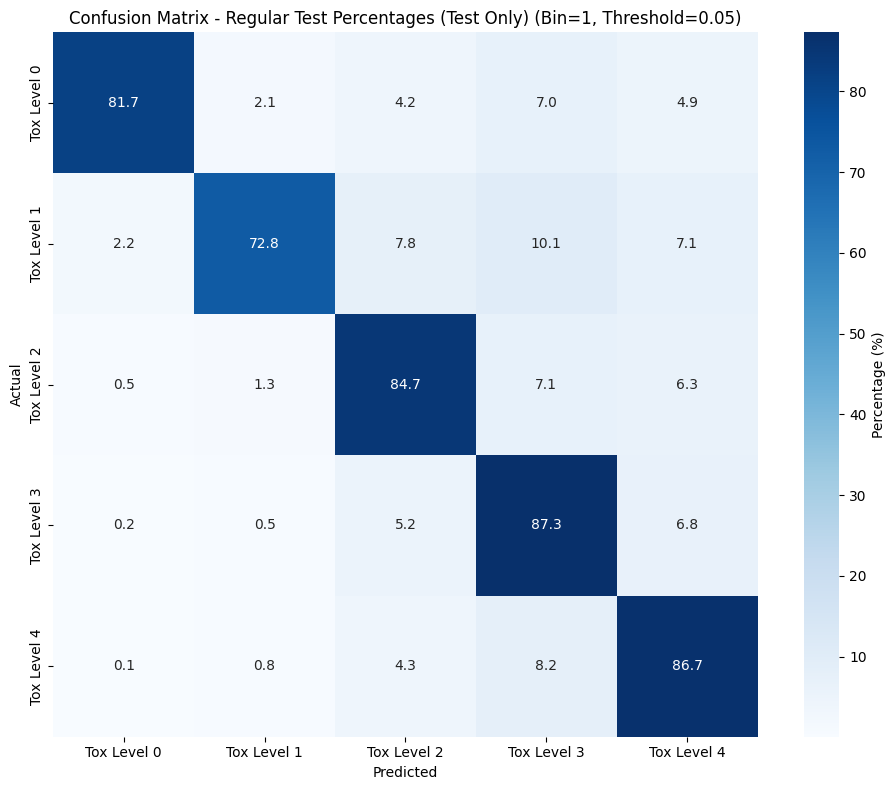


Percentage breakdown by actual label (Bin=1, Threshold=0.05):

Tox Level 0 (Total: 142 samples):
  → Tox Level 0: 81.7% (116/142 samples)
  → Tox Level 1: 2.1% (3/142 samples)
  → Tox Level 2: 4.2% (6/142 samples)
  → Tox Level 3: 7.0% (10/142 samples)
  → Tox Level 4: 4.9% (7/142 samples)

Tox Level 1 (Total: 268 samples):
  → Tox Level 0: 2.2% (6/268 samples)
  → Tox Level 1: 72.8% (195/268 samples)
  → Tox Level 2: 7.8% (21/268 samples)
  → Tox Level 3: 10.1% (27/268 samples)
  → Tox Level 4: 7.1% (19/268 samples)

Tox Level 2 (Total: 1697 samples):
  → Tox Level 0: 0.5% (9/1697 samples)
  → Tox Level 1: 1.3% (22/1697 samples)
  → Tox Level 2: 84.7% (1438/1697 samples)
  → Tox Level 3: 7.1% (121/1697 samples)
  → Tox Level 4: 6.3% (107/1697 samples)

Tox Level 3 (Total: 3939 samples):
  → Tox Level 0: 0.2% (8/3939 samples)
  → Tox Level 1: 0.5% (18/3939 samples)
  → Tox Level 2: 5.2% (206/3939 samples)
  → Tox Level 3: 87.3% (3439/3939 samples)
  → Tox Level 4: 6.8% (268/3939 sampl

In [62]:
# Regular Test Percentage Confusion Matrix
cm_percent, df_analysis = create_percentage_confusion_matrix_standalone(
    folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/",
    folder_name="cond_enc_134e1e2_2stepclassi_df6",
    bin_size=1,
    threshold_size=0.05,
    use_super_test=False,
    save_plots=False,
    test_only=True
)

Filtered to test-only spectra: 413/413 samples (100.0%)


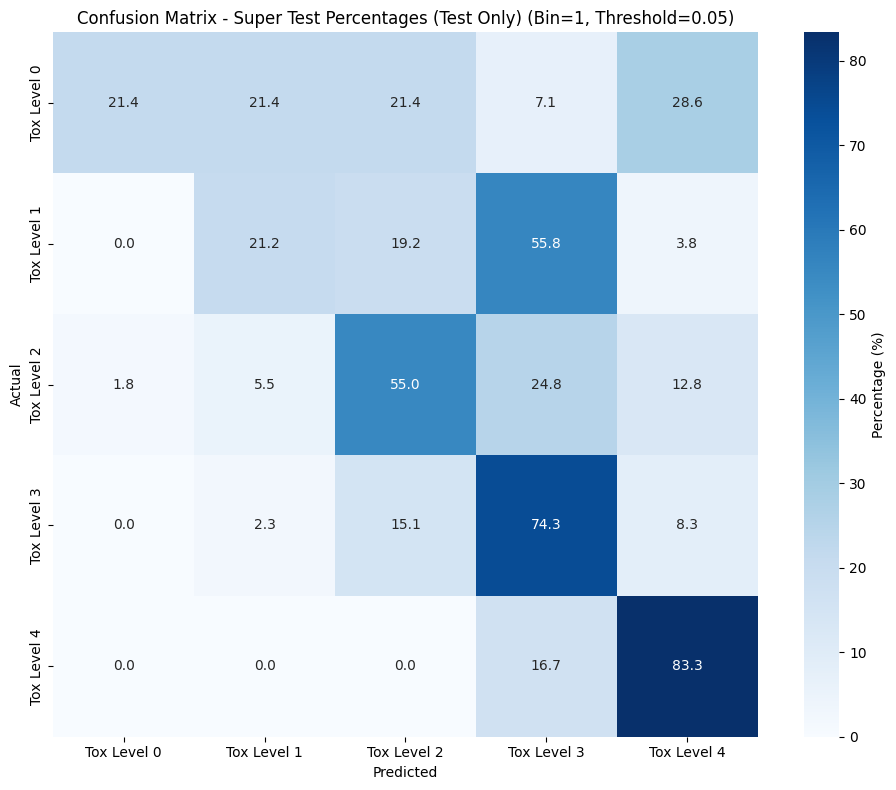


Percentage breakdown by actual label (Bin=1, Threshold=0.05):

Tox Level 0 (Total: 28 samples):
  → Tox Level 0: 21.4% (6/28 samples)
  → Tox Level 1: 21.4% (6/28 samples)
  → Tox Level 2: 21.4% (6/28 samples)
  → Tox Level 3: 7.1% (2/28 samples)
  → Tox Level 4: 28.6% (8/28 samples)

Tox Level 1 (Total: 52 samples):
  → Tox Level 0: 0.0% (0/52 samples)
  → Tox Level 1: 21.2% (11/52 samples)
  → Tox Level 2: 19.2% (10/52 samples)
  → Tox Level 3: 55.8% (29/52 samples)
  → Tox Level 4: 3.8% (2/52 samples)

Tox Level 2 (Total: 109 samples):
  → Tox Level 0: 1.8% (2/109 samples)
  → Tox Level 1: 5.5% (6/109 samples)
  → Tox Level 2: 55.0% (60/109 samples)
  → Tox Level 3: 24.8% (27/109 samples)
  → Tox Level 4: 12.8% (14/109 samples)

Tox Level 3 (Total: 218 samples):
  → Tox Level 0: 0.0% (0/218 samples)
  → Tox Level 1: 2.3% (5/218 samples)
  → Tox Level 2: 15.1% (33/218 samples)
  → Tox Level 3: 74.3% (162/218 samples)
  → Tox Level 4: 8.3% (18/218 samples)

Tox Level 4 (Total: 6 samp

In [63]:
# Super Test Percentage Confusion Matrix
cm_percent, df_analysis = create_percentage_confusion_matrix_standalone(
    folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/",
    folder_name="cond_enc_134e1e2_2stepclassi_df6_super_test",
    bin_size=1,
    threshold_size=0.05,
    use_super_test=True, 
    save_plots=False,
    test_only=True
)

Filtered to test-only spectra: 7222/14859 samples (48.6%)


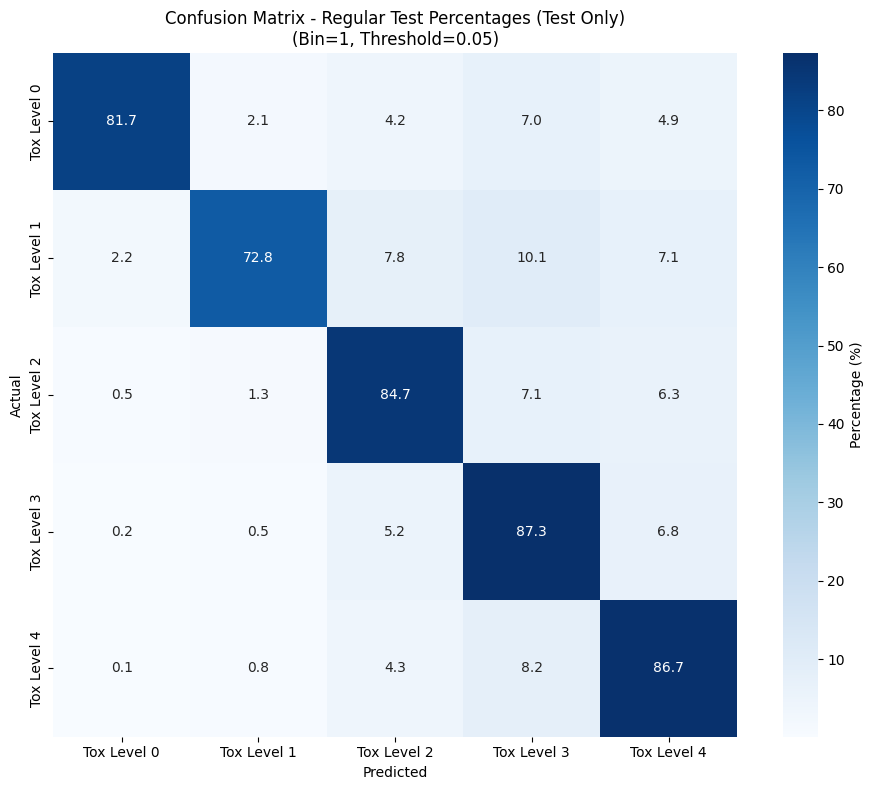


Percentage breakdown by actual label (Bin=1, Threshold=0.05):

Tox Level 0 (Total: 142 samples):
  → Tox Level 0: 81.7% (116/142 samples)
  → Tox Level 1: 2.1% (3/142 samples)
  → Tox Level 2: 4.2% (6/142 samples)
  → Tox Level 3: 7.0% (10/142 samples)
  → Tox Level 4: 4.9% (7/142 samples)

Tox Level 1 (Total: 268 samples):
  → Tox Level 0: 2.2% (6/268 samples)
  → Tox Level 1: 72.8% (195/268 samples)
  → Tox Level 2: 7.8% (21/268 samples)
  → Tox Level 3: 10.1% (27/268 samples)
  → Tox Level 4: 7.1% (19/268 samples)

Tox Level 2 (Total: 1697 samples):
  → Tox Level 0: 0.5% (9/1697 samples)
  → Tox Level 1: 1.3% (22/1697 samples)
  → Tox Level 2: 84.7% (1438/1697 samples)
  → Tox Level 3: 7.1% (121/1697 samples)
  → Tox Level 4: 6.3% (107/1697 samples)

Tox Level 3 (Total: 3939 samples):
  → Tox Level 0: 0.2% (8/3939 samples)
  → Tox Level 1: 0.5% (18/3939 samples)
  → Tox Level 2: 5.2% (206/3939 samples)
  → Tox Level 3: 87.3% (3439/3939 samples)
  → Tox Level 4: 6.8% (268/3939 sampl

In [64]:
# (OLDER VERSION) Example 1: Confusion Matrix
cm_percent, df = create_confusion_matrix_general(
    folder_path="/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_134e1e2_2stepclassi_df6",
    bin_val=1,
    threshold_val=0.05,
    pred_class_col='cond_tox_pred_class',  # Fixed: was 'cond_enc_pred_class'
    response_col='Response',
    file_prefix='cond_enc',  # Change this based on the input
    use_super_test=False,
    test_only=True
)


## 2 step model means and stds confusion matrix

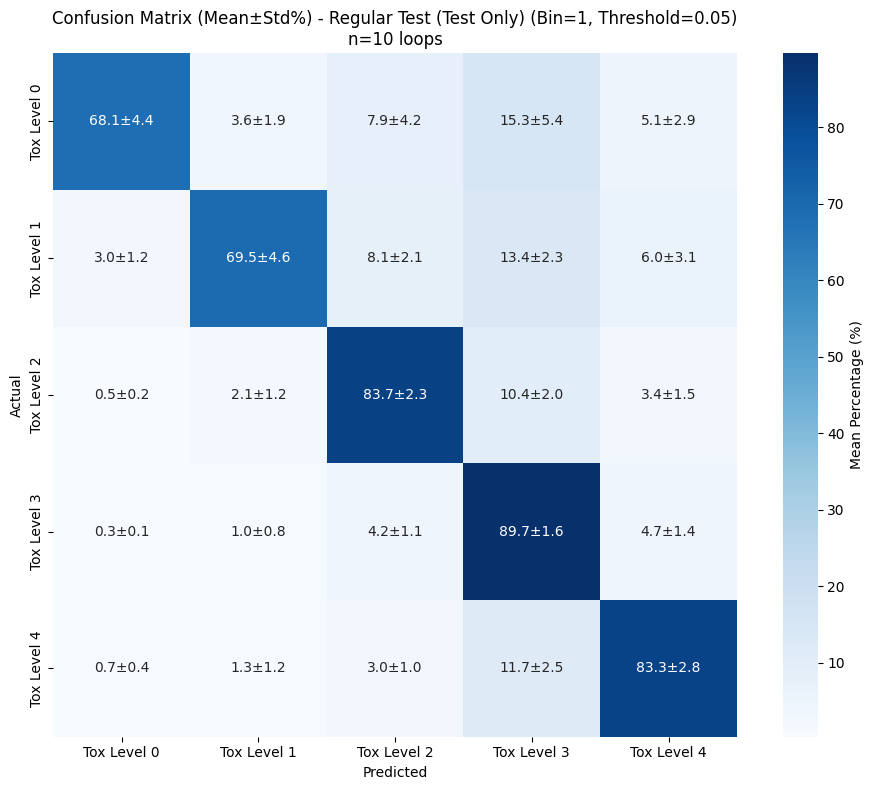

In [139]:
# Regular Confusion Matrix
create_percentage_confusion_matrix_mean_std(folder='/home/dlipsey/MITLincolnLabs/MIT_LL_data/', 
                                            folder_name='2step_cond_enc_134_loop', 
                                            bin_size=1, threshold_size=0.05, 
                                            use_super_test=False, 
                                            save_plots=False, 
                                            test_only=True,
                                            num_loops=10) # None for all

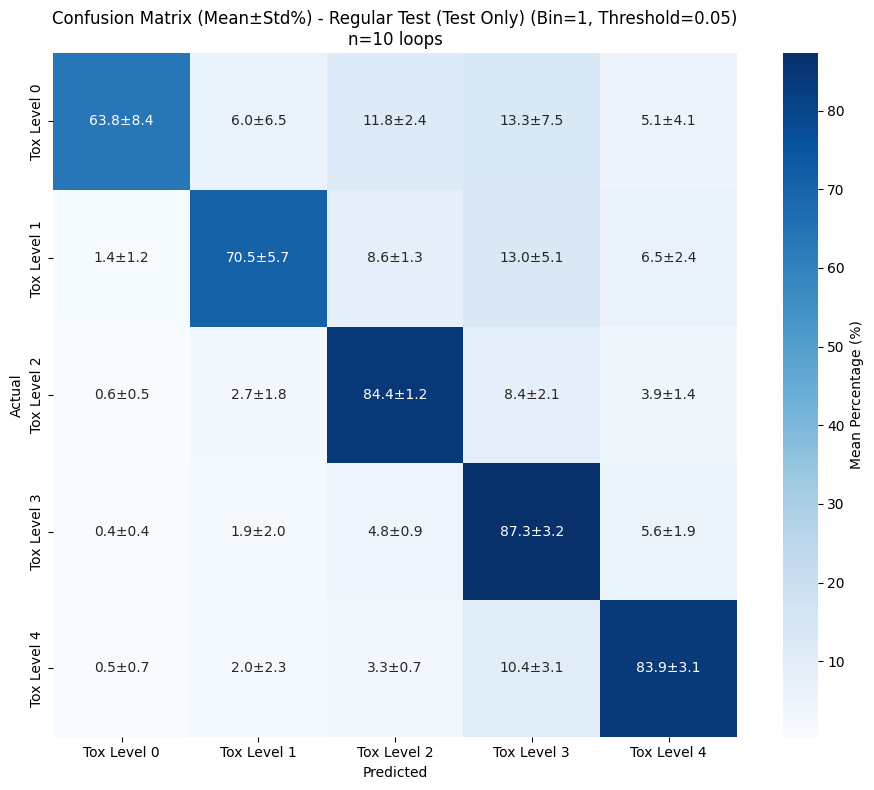

In [141]:
# Synthetic Ablation Confusion Matrix 
create_percentage_confusion_matrix_mean_std(folder='/home/dlipsey/MITLincolnLabs/MIT_LL_data/', 
                                            folder_name='2step_synth_abl_134_loop', 
                                            bin_size=1, threshold_size=0.05, 
                                            use_super_test=False, 
                                            save_plots=False, 
                                            test_only=True,
                                            num_loops=10) # None for all

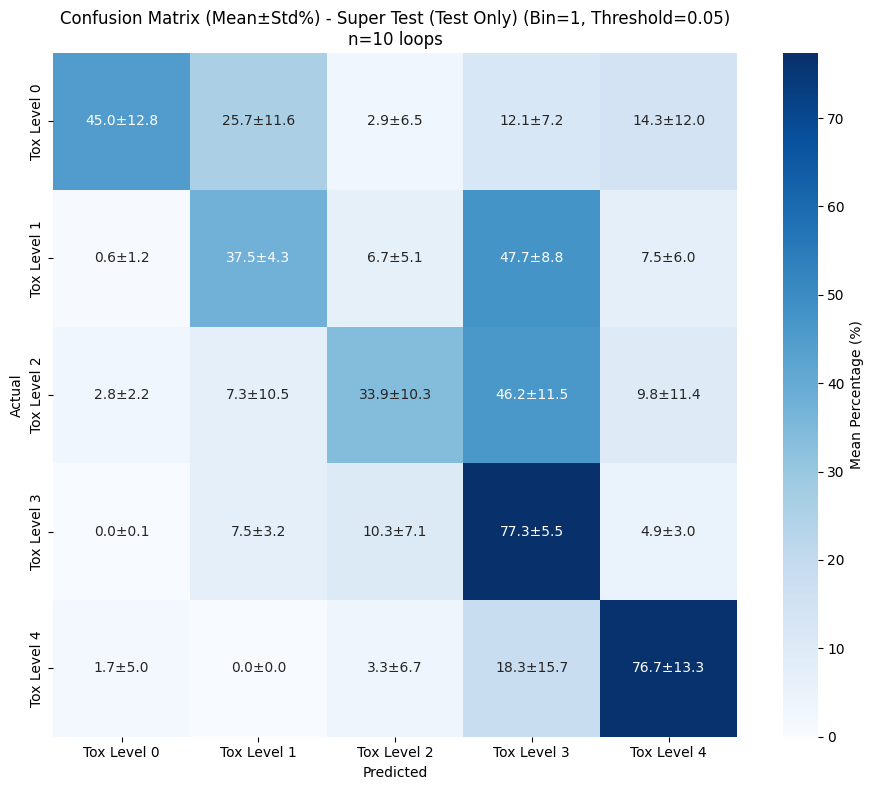

In [116]:
# Super Test Confusion Matrix
create_percentage_confusion_matrix_mean_std(folder='/home/dlipsey/MITLincolnLabs/MIT_LL_data/', 
                                            folder_name='2step_cond_enc_134_loop_super_test', 
                                            bin_size=1, threshold_size=0.05, 
                                            use_super_test=True, 
                                            save_plots=False, 
                                            test_only=True,
                                            num_loops=10) # None for all

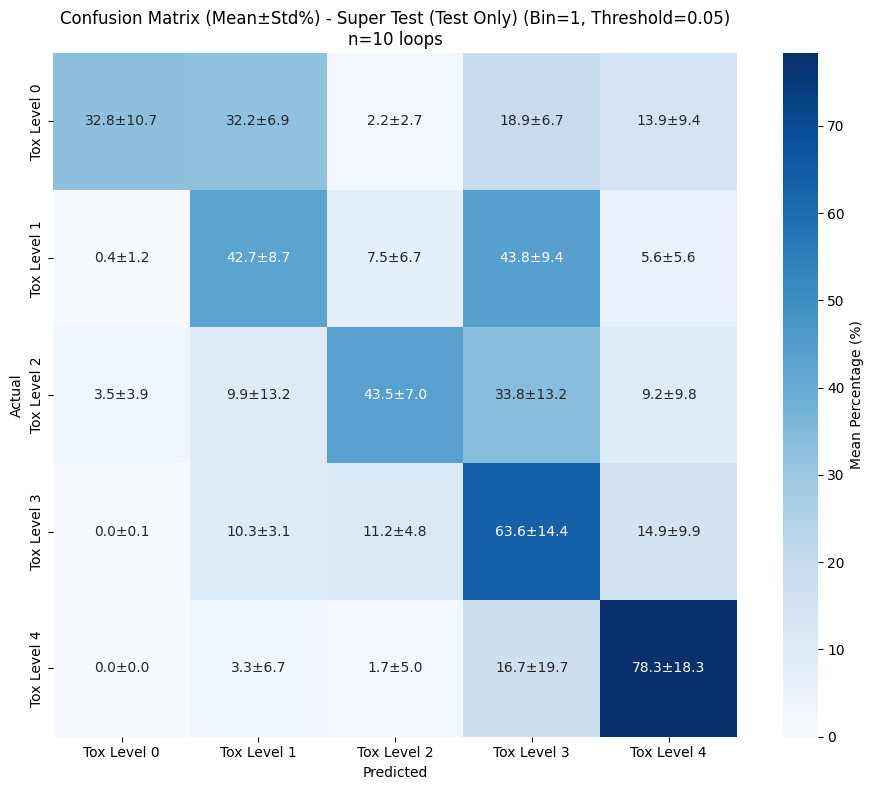

In [117]:
# Synthetic Ablation Super Test Confusion Matrix
create_percentage_confusion_matrix_mean_std(folder='/home/dlipsey/MITLincolnLabs/MIT_LL_data/', 
                                            folder_name='2step_synth_abl_134_loop_super_test', 
                                            bin_size=1, threshold_size=0.05, 
                                            use_super_test=True, 
                                            save_plots=False, 
                                            test_only=True,
                                            num_loops=10) # None for all

## Direct tocicity prediciton MLP

Filtered to test-only spectra: 7222/14859 samples (48.6%)


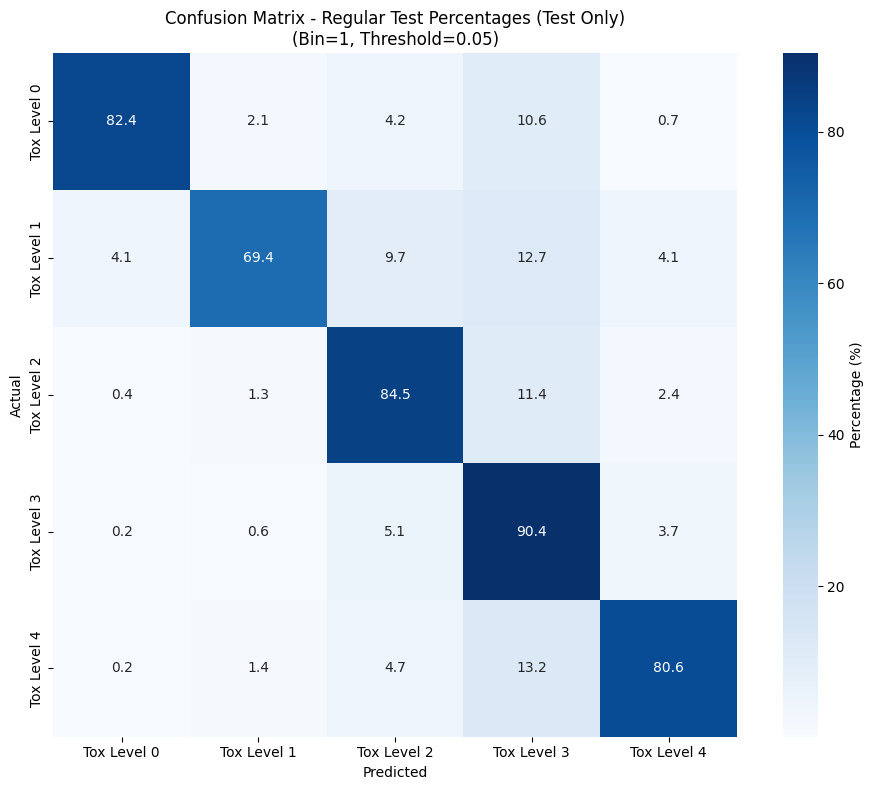


Percentage breakdown by actual label (Bin=1, Threshold=0.05):

Tox Level 0 (Total: 142 samples):
  → Tox Level 0: 82.4% (117/142 samples)
  → Tox Level 1: 2.1% (3/142 samples)
  → Tox Level 2: 4.2% (6/142 samples)
  → Tox Level 3: 10.6% (15/142 samples)
  → Tox Level 4: 0.7% (1/142 samples)

Tox Level 1 (Total: 268 samples):
  → Tox Level 0: 4.1% (11/268 samples)
  → Tox Level 1: 69.4% (186/268 samples)
  → Tox Level 2: 9.7% (26/268 samples)
  → Tox Level 3: 12.7% (34/268 samples)
  → Tox Level 4: 4.1% (11/268 samples)

Tox Level 2 (Total: 1697 samples):
  → Tox Level 0: 0.4% (7/1697 samples)
  → Tox Level 1: 1.3% (22/1697 samples)
  → Tox Level 2: 84.5% (1434/1697 samples)
  → Tox Level 3: 11.4% (194/1697 samples)
  → Tox Level 4: 2.4% (40/1697 samples)

Tox Level 3 (Total: 3939 samples):
  → Tox Level 0: 0.2% (7/3939 samples)
  → Tox Level 1: 0.6% (25/3939 samples)
  → Tox Level 2: 5.1% (202/3939 samples)
  → Tox Level 3: 90.4% (3559/3939 samples)
  → Tox Level 4: 3.7% (146/3939 sam

In [69]:
# Direct prediction Confusion Matrix
cm_percent, df = create_confusion_matrix_general(
    folder_path="/home/dlipsey/MITLincolnLabs/MIT_LL_data/regular_classifier_df6",
    bin_val=1,
    threshold_val=0.05,
    pred_class_col='direct_tox_pred_class',  # Change this based on the input
    response_col='Response',
    file_prefix='direct_tox',  # Change this based on the input
    use_super_test=False,
    test_only=True
)

Filtered to test-only spectra: 413/413 samples (100.0%)


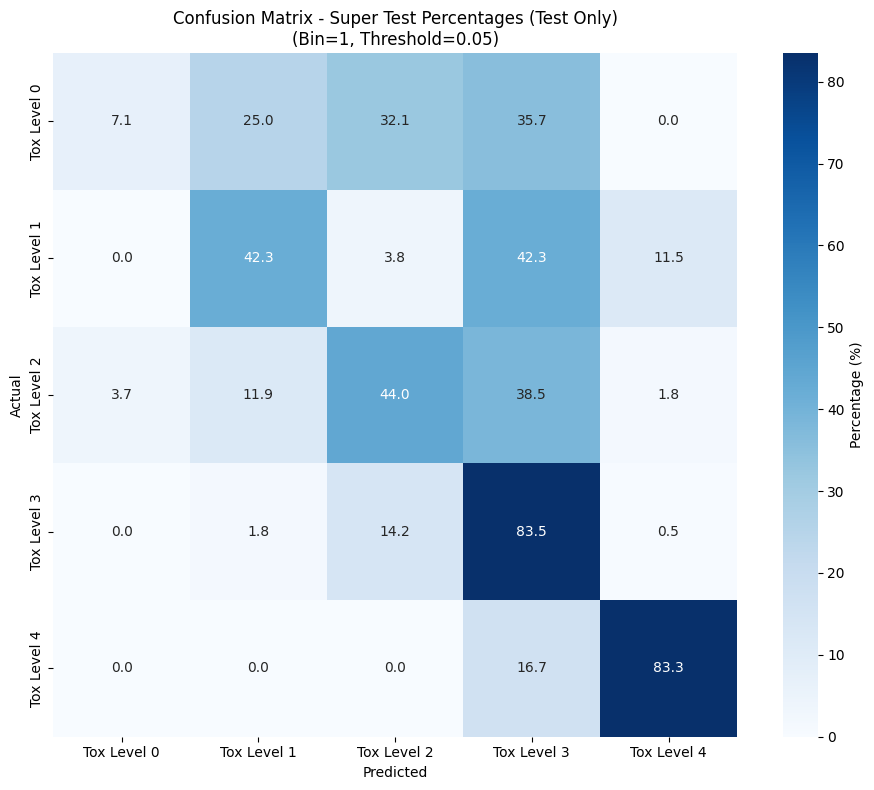


Percentage breakdown by actual label (Bin=1, Threshold=0.05):

Tox Level 0 (Total: 28 samples):
  → Tox Level 0: 7.1% (2/28 samples)
  → Tox Level 1: 25.0% (7/28 samples)
  → Tox Level 2: 32.1% (9/28 samples)
  → Tox Level 3: 35.7% (10/28 samples)
  → Tox Level 4: 0.0% (0/28 samples)

Tox Level 1 (Total: 52 samples):
  → Tox Level 0: 0.0% (0/52 samples)
  → Tox Level 1: 42.3% (22/52 samples)
  → Tox Level 2: 3.8% (2/52 samples)
  → Tox Level 3: 42.3% (22/52 samples)
  → Tox Level 4: 11.5% (6/52 samples)

Tox Level 2 (Total: 109 samples):
  → Tox Level 0: 3.7% (4/109 samples)
  → Tox Level 1: 11.9% (13/109 samples)
  → Tox Level 2: 44.0% (48/109 samples)
  → Tox Level 3: 38.5% (42/109 samples)
  → Tox Level 4: 1.8% (2/109 samples)

Tox Level 3 (Total: 218 samples):
  → Tox Level 0: 0.0% (0/218 samples)
  → Tox Level 1: 1.8% (4/218 samples)
  → Tox Level 2: 14.2% (31/218 samples)
  → Tox Level 3: 83.5% (182/218 samples)
  → Tox Level 4: 0.5% (1/218 samples)

Tox Level 4 (Total: 6 sample

In [70]:
# Super Test Direct Prediction Confusion Matrix
cm_percent, df = create_confusion_matrix_general(
    folder_path="/home/dlipsey/MITLincolnLabs/MIT_LL_data/regular_classifier_df6_super_test",
    bin_val=1,
    threshold_val=0.05,
    pred_class_col='direct_tox_pred_class',  # Change this based on the input
    response_col='Response',
    file_prefix='direct_tox',  # Change this based on the input
    use_super_test=True,
    test_only=True
)

## Direct Prediction means and stds confusion matrix.

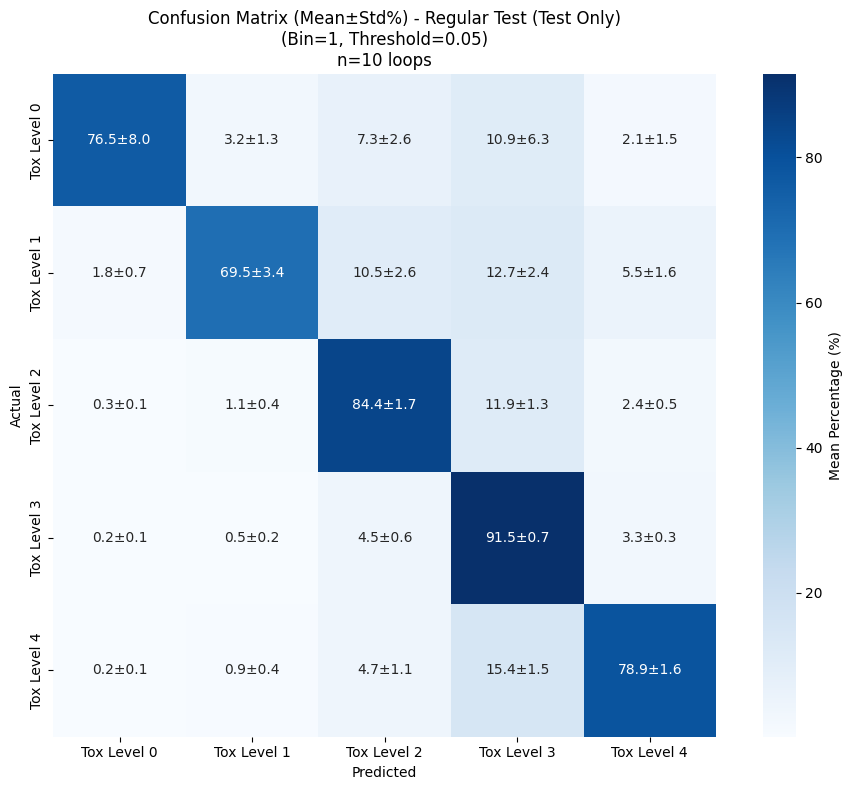

In [147]:
# Direct Prediction Regular Confusion Matrix
create_confusion_matrix_general_mean_std(
    folder_path='/home/dlipsey/MITLincolnLabs/MIT_LL_data/regular_classifier_loop',
    bin_val=1,
    threshold_val=0.05,
    pred_class_col='direct_tox_pred_class',
    response_col='Response',
    train_col='train',
    file_prefix='direct_tox',
    use_super_test=False,
    test_only=True,
    save_plots=False,
    figsize=(10, 8),
    num_loops=10) # None for all

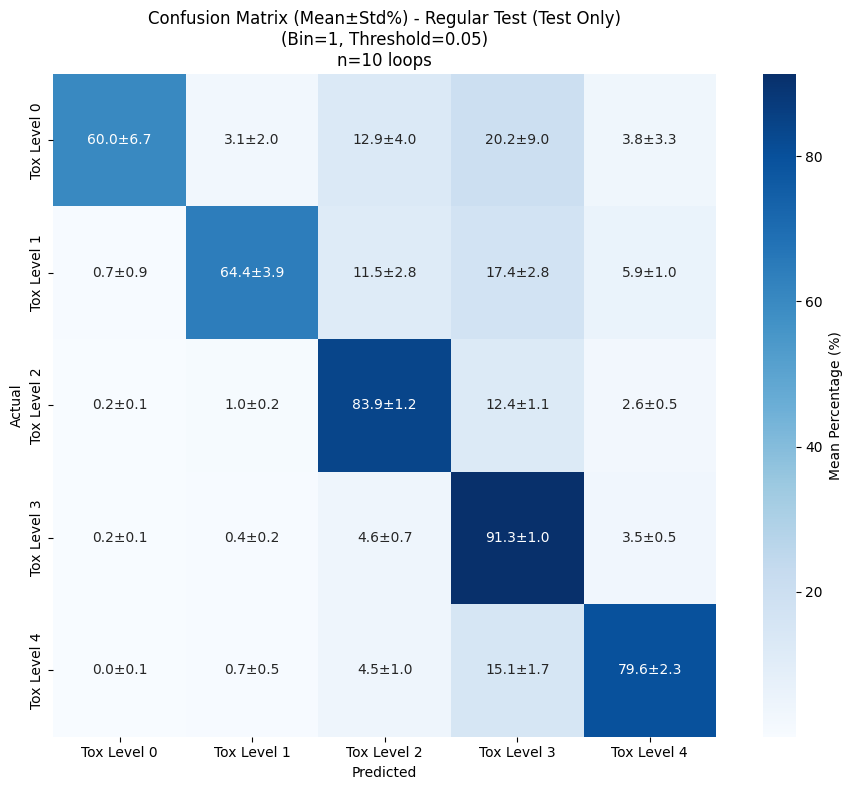

In [128]:
# Synthetic Ablation Direct Prediction Confusion Matrix
create_confusion_matrix_general_mean_std(
    folder_path='/home/dlipsey/MITLincolnLabs/MIT_LL_data/regular_classifier_synth_abl_loop',
    bin_val=1,
    threshold_val=0.05,
    pred_class_col='direct_tox_pred_class',
    response_col='Response',
    train_col='train',
    file_prefix='direct_tox',
    use_super_test=False,
    test_only=True,
    save_plots=False,
    figsize=(10, 8),
    num_loops=10) # None for all

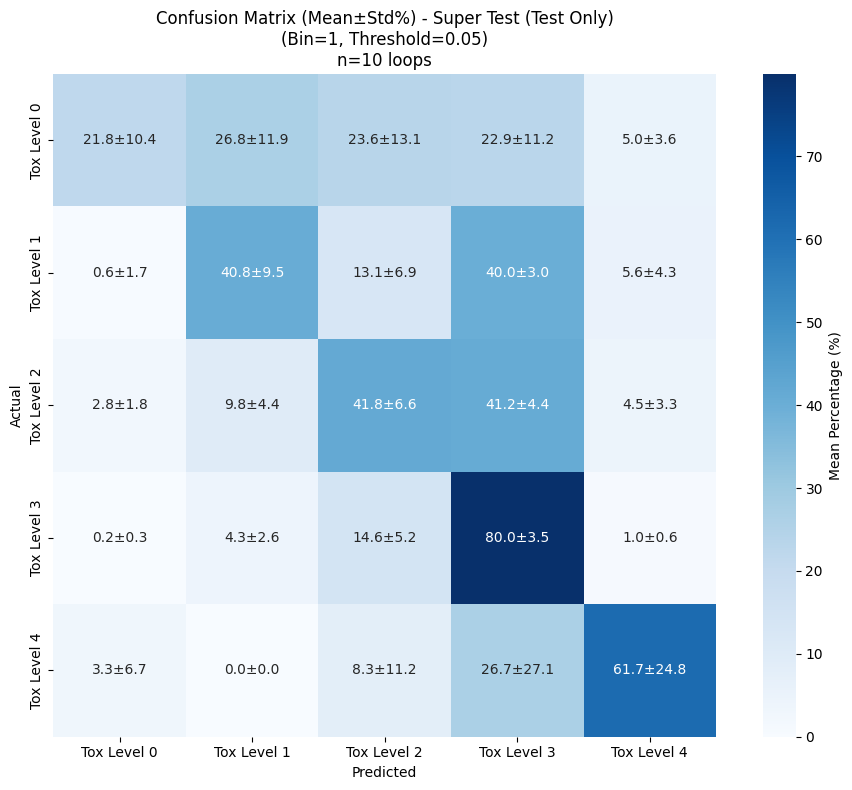

In [105]:
# Regular Super Test Direct Prediction Confusion Matrix
create_confusion_matrix_general_mean_std(
    folder_path='/home/dlipsey/MITLincolnLabs/MIT_LL_data/regular_classifier_loop_super_test',
    bin_val=1,
    threshold_val=0.05,
    pred_class_col='direct_tox_pred_class',
    response_col='Response',
    train_col='train',
    file_prefix='direct_tox',
    use_super_test=True,
    test_only=True,
    save_plots=False,
    figsize=(10, 8),
    num_loops=10) # None for all

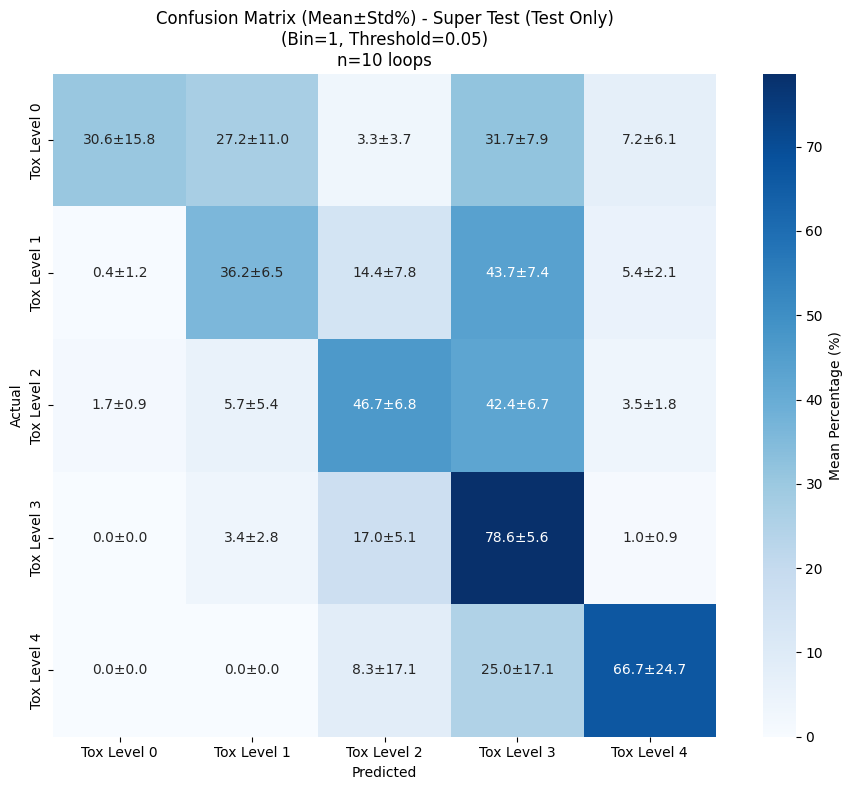

In [106]:
# Synthetic Ablation Super Test Direct Prediction Confusion Matrix
create_confusion_matrix_general_mean_std(
    folder_path='/home/dlipsey/MITLincolnLabs/MIT_LL_data/regular_classifier_synth_abl_loop_super_test',
    bin_val=1,
    threshold_val=0.05,
    pred_class_col='direct_tox_pred_class',
    response_col='Response',
    train_col='train',
    file_prefix='direct_tox',
    use_super_test=True,
    test_only=True,
    save_plots=False,
    figsize=(10, 8),
    num_loops=10) # None for all

In [75]:
# super_test_smiles = [
#     'COC(=O)C=C(C)OP(=O)(OC)OC',
#     'COc1cc2c(c3oc(=O)c4c(c13)CCC4=O)[C@@H]1C=CO[C@@H]1O2',
#     'CC(=O)OC1(C)CC(C)C(=O)C(C(O)CC2CC(=O)NC(=O)C2)C1',
#     'C[C@H]1O[C@@H](O[C@H]2[C@@H](O)C[C@H](O[C@H]3[C@@H](O)C[C@H](O[C@H]4CC[C@@]5(C)[C@H](CC[C@@H]6[C@@H]5C[C@@H](O)[C@]5(C)[C@@H](C7=CC(=O)OC7)CC[C@]65O)C4)O[C@@H]3C)O[C@@H]2C)C[C@H](O)[C@@H]1O',
#     'CNC(=O)Oc1cc(C)cc(C(C)C)c1',
#     'CNC(=O)Oc1ccc(N(C)C)c(C)c1',
#     'C[C@@H]1Cc2c(Cl)cc(C(=O)N[C@@H](Cc3ccccc3)C(=O)O)c(O)c2C(=O)O1',
#     'COc1ccc2c(c1)c(CC(=O)OCC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc1',
#     'CC(C)(C)CC(C)(C)c1ccc(OCCOCC[N+](C)(C)Cc2ccccc2)cc1',
#     'CC(=O)N1CCN(c2ccc(OC[C@H]3CO[C@](Cn4ccnc4)(c4ccc(Cl)cc4Cl)O3)cc2)CC1',
#     'c1ccc(C2CN3CCSC3=N2)cc1',
#     'CN(C)CCC=C1c2ccccc2CCc2ccccc21',
#     'CCOP(=S)(OCC)Oc1ccc2c(C)c(Cl)c(=O)oc2c1',
#     'CC(C)NCC(O)COc1cccc2ccccc12',
#     'CCOC(=O)C(C)(C)Oc1ccc(Cl)cc1',
#     'CCN(CC)CCNC(=O)c1cc(Cl)c(N)cc1OC',
#     'COc1ccc2c(c1OC)C(=O)OC2C1c2cc3c(cc2CCN1C)OCO3',
#     'CN(C)c1ccc(SC#N)cc1',
#     'CC(C)[C@H](N)C(=O)O',
#     'CCCCOC(=O)COC(=O)c1ccccc1C(=O)OCCCC',
#     'NC(C(=O)O)c1ccccc1'
# ]

# df3 = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_spectra.parquet')
# print('Original shape:', df3.shape)

# # Remove super test SMILES
# filtered_df3 = df3[~df3['SMILES_spectra'].isin(super_test_smiles)]
# print('Shape after removing super test SMILES:', filtered_df3.shape)

# # Filter out SMILES with less than 4 spectra
# smiles_counts = filtered_df3['SMILES_spectra'].value_counts()
# valid_smiles = smiles_counts[smiles_counts >= 4].index
# filtered_df3 = filtered_df3[filtered_df3['SMILES_spectra'].isin(valid_smiles)]
# print('Filtered shape:', filtered_df3.shape)

# # Count synthetic SMILES after filtering
# synthetic_count = filtered_df3[filtered_df3['synthetic'] == 1].shape[0]
# print('Synthetic count after filtering:', synthetic_count)

# Global Heatmaps

## 2 step algorithm - Conditional Encoder -> Toxicity MLP

In [ ]:
# Older Version Accuracy Heatmap
accuracy_pivot = create_accuracy_heatmap_general(
    folder_path="/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_134e1e2_2stepclassi_df6",
    file_prefix='cond_enc',
    pred_class_col='cond_tox_pred_class',
    metric='average',  # or '1', '2', '3', '4'
    use_super_test=False
)

  cond_enc_bin0_05_thresh0_001_df_spectra: Filtered to test-only - 7222/14859 samples
  cond_enc_bin0_1_thresh0_001_df_spectra: Filtered to test-only - 7222/14859 samples
  cond_enc_bin0_1_thresh0_005_df_spectra: Filtered to test-only - 7222/14859 samples
  cond_enc_bin0_1_thresh0_01_df_spectra: Filtered to test-only - 7222/14859 samples
  cond_enc_bin0_1_thresh0_05_df_spectra: Filtered to test-only - 7222/14859 samples
  cond_enc_bin0_1_thresh0_1_df_spectra: Filtered to test-only - 7222/14859 samples
  cond_enc_bin0_1_thresh0_5_df_spectra: Filtered to test-only - 7222/14859 samples
  cond_enc_bin0_1_thresh100_df_spectra: Filtered to test-only - 7222/14859 samples
  cond_enc_bin0_1_thresh10_df_spectra: Filtered to test-only - 7222/14859 samples
  cond_enc_bin0_1_thresh1_df_spectra: Filtered to test-only - 7222/14859 samples
  cond_enc_bin0_1_thresh2_df_spectra: Filtered to test-only - 7222/14859 samples
  cond_enc_bin0_1_thresh50_df_spectra: Filtered to test-only - 7222/14859 samples
 

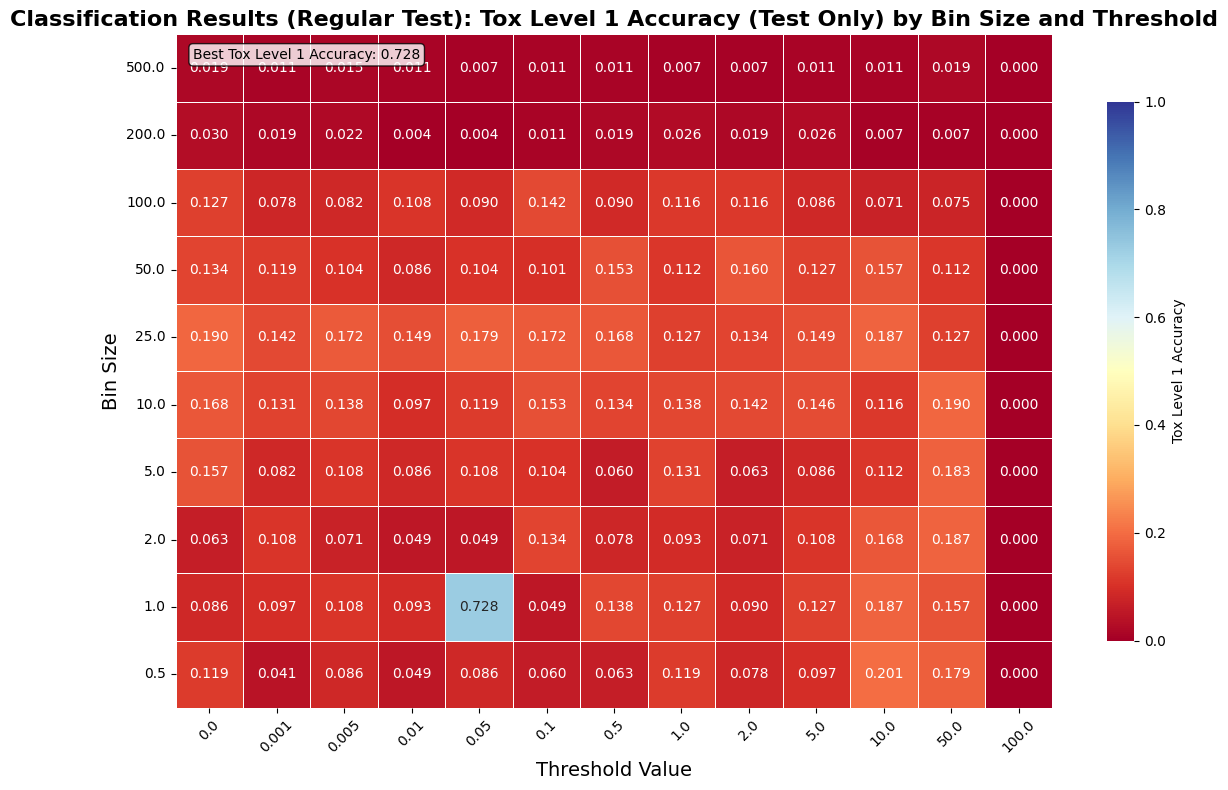

In [ ]:
# Regular test datasets
folder_path = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_134e1e2_2stepclassi_df6"
create_detailed_heatmap_cond_enc_accuracy_v2(folder_path, 
                                             metric='1', 
                                             colormap='RdYlBu', #'RdYlGn'
                                             use_super_test=False,
                                             threshold_values = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100],
                                             bin_values = [0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500],
                                             test_only=True)
# other metrics 1 2 3 4 average
# threshold_values = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
# bin_values = [0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500]

  super_test_cond_enc_bin0_05_thresh0_001_df_spectra: Filtered to test-only - 413/413 samples
  super_test_cond_enc_bin0_1_thresh0_001_df_spectra: Filtered to test-only - 413/413 samples
  super_test_cond_enc_bin0_1_thresh0_005_df_spectra: Filtered to test-only - 413/413 samples
  super_test_cond_enc_bin0_1_thresh0_01_df_spectra: Filtered to test-only - 413/413 samples
  super_test_cond_enc_bin0_1_thresh0_05_df_spectra: Filtered to test-only - 413/413 samples
  super_test_cond_enc_bin0_1_thresh0_1_df_spectra: Filtered to test-only - 413/413 samples
  super_test_cond_enc_bin0_1_thresh0_5_df_spectra: Filtered to test-only - 413/413 samples
  super_test_cond_enc_bin0_1_thresh100_df_spectra: Filtered to test-only - 413/413 samples
  super_test_cond_enc_bin0_1_thresh10_df_spectra: Filtered to test-only - 413/413 samples
  super_test_cond_enc_bin0_1_thresh1_df_spectra: Filtered to test-only - 413/413 samples
  super_test_cond_enc_bin0_1_thresh2_df_spectra: Filtered to test-only - 413/413 sam

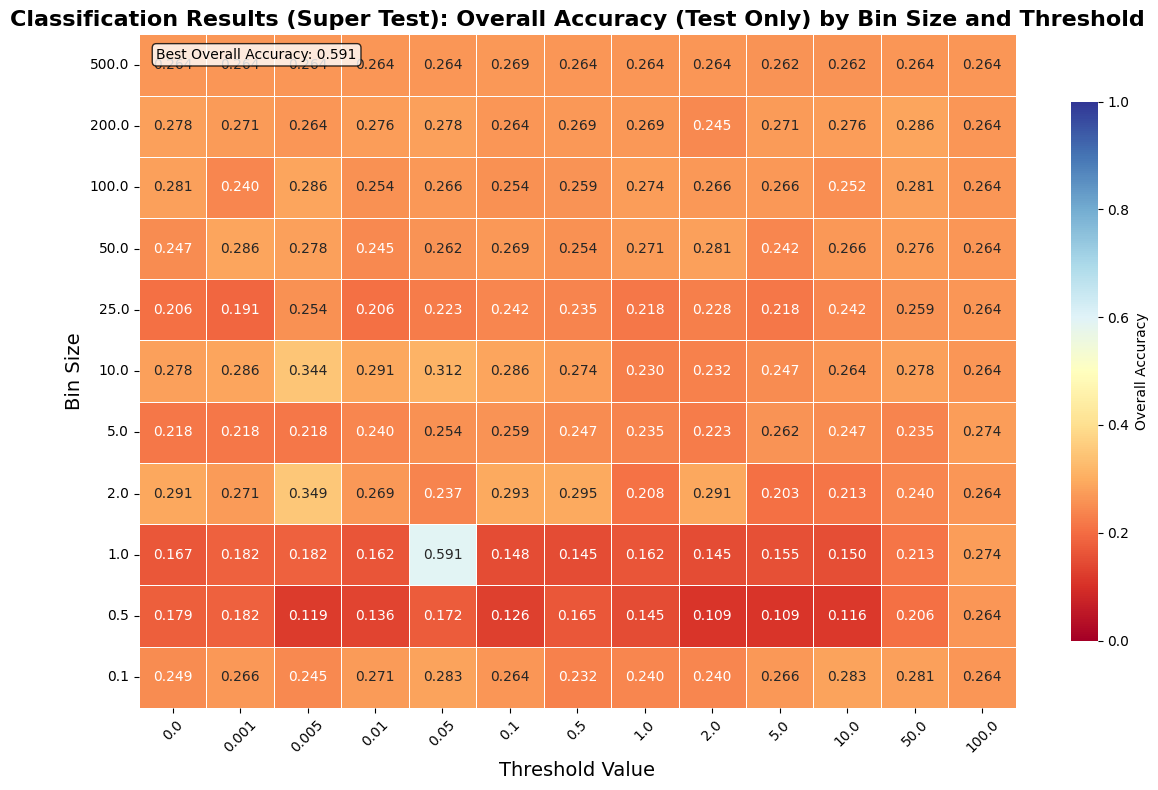

In [ ]:
# Super test datasets
folder_path = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_134e1e2_2stepclassi_df6_super_test"
create_detailed_heatmap_cond_enc_accuracy_v2(folder_path, metric='average', 
                                             colormap='RdYlBu',
                                             use_super_test=True, 
                                             threshold_values = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100],
                                             bin_values = [0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500],
                                             test_only=True)
# other metrics 1 2 3 4 average
# threshold_values = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
# bin_values = [0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500]

## Direct tocicity prediciton MLP

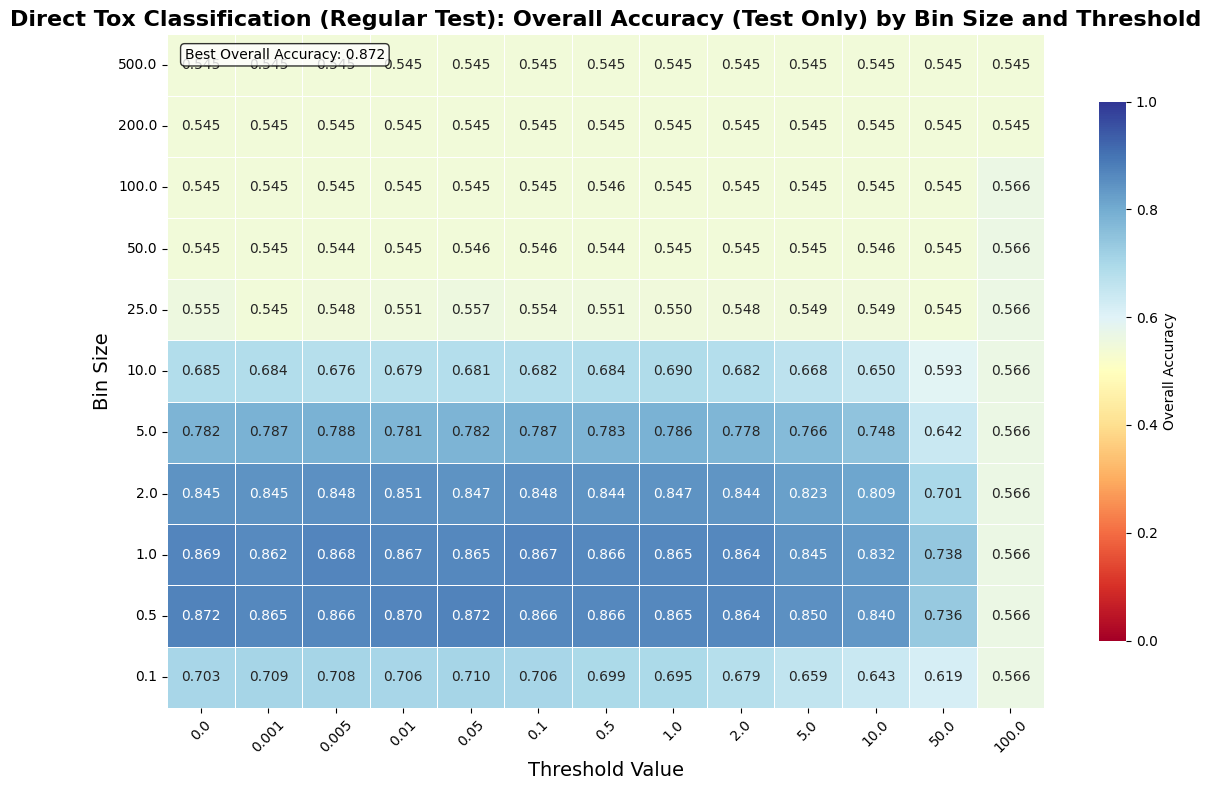

In [ ]:
# Set your data folder (with .parquet files)
data_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/regular_classifier_df6"

# Plot OVERALL ACCURACY for regular (non-super test) files
create_accuracy_heatmap_for_direct_tox(
    folder_path=data_folder,
    metric='average',   # 'average' or '0', '1', '2', '3' for per-class accuracy 
    colormap='RdYlBu', #'RdYlGn', #
    figsize=(12, 8),
    use_super_test=False,  
    threshold_values = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100],
    bin_values = [0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500],
    test_only=True         
)

# threshold_values = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
# bin_values = [0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500]

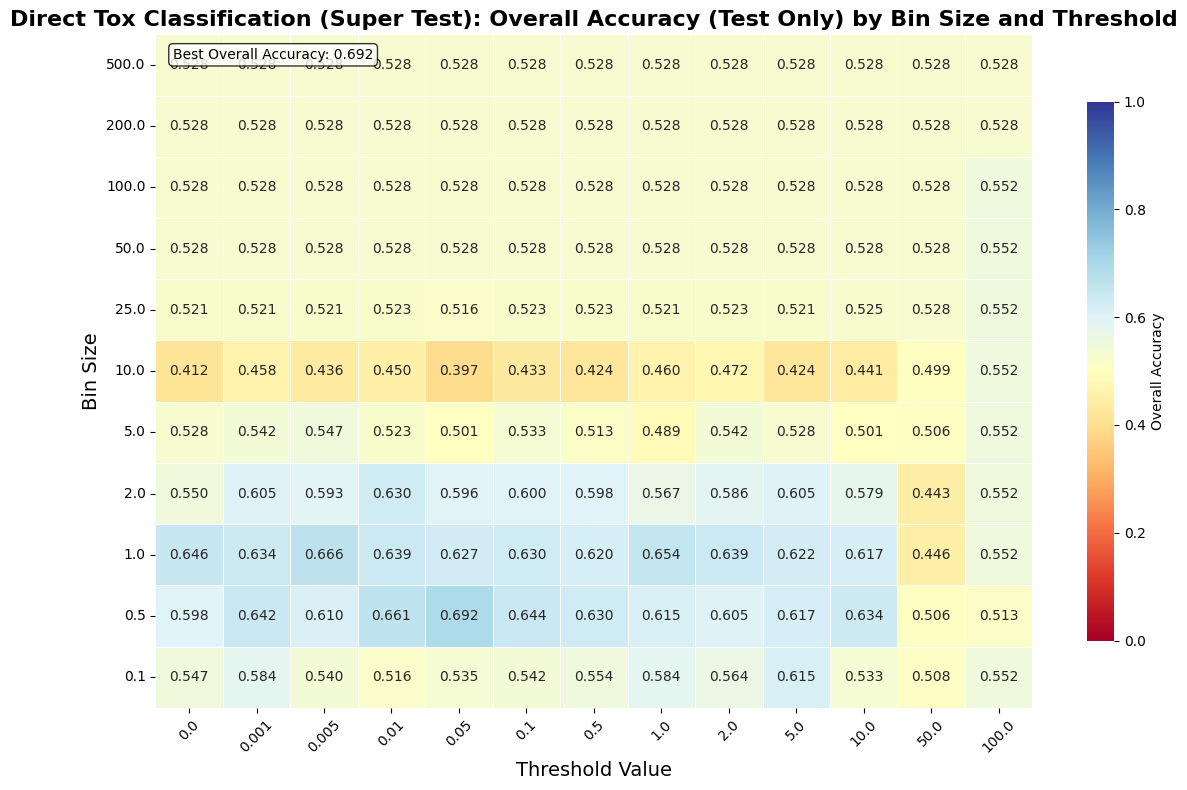

In [ ]:
# Super Test set
data_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/regular_classifier_df6_super_test"

# Plot OVERALL ACCURACY for super test files (if present)
create_accuracy_heatmap_for_direct_tox(
    folder_path=data_folder,
    metric='average', # 'average' or '0', '1', '2', '3' for per-class accuracy
    colormap='RdYlBu', # 'RdYlGn'
    figsize=(12, 8),
    use_super_test=True,
    threshold_values = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100],
    bin_values = [0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500],
    test_only=True,
)
# threshold_values = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
# bin_values = [0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500]


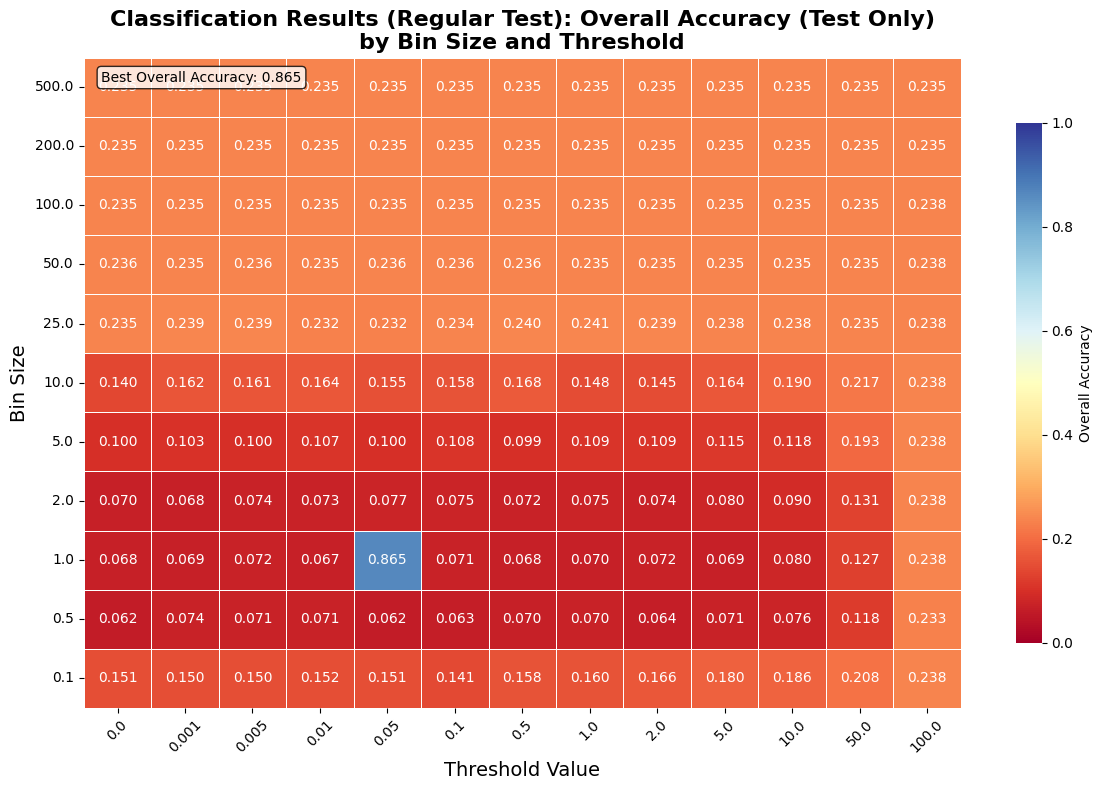

In [ ]:
# Example 2: Accuracy Heatmap
accuracy_pivot = create_accuracy_heatmap_general(
    folder_path="/home/dlipsey/MITLincolnLabs/MIT_LL_data/regular_classifier_df6",
    file_prefix='direct_tox',
    pred_class_col='direct_tox_pred_class',
    metric='average',  # or '1', '2', '3', '4'
    colormap='RdYlBu',
    use_super_test=False
)

# ChemNet PCA Plots

## Single PCA Plot

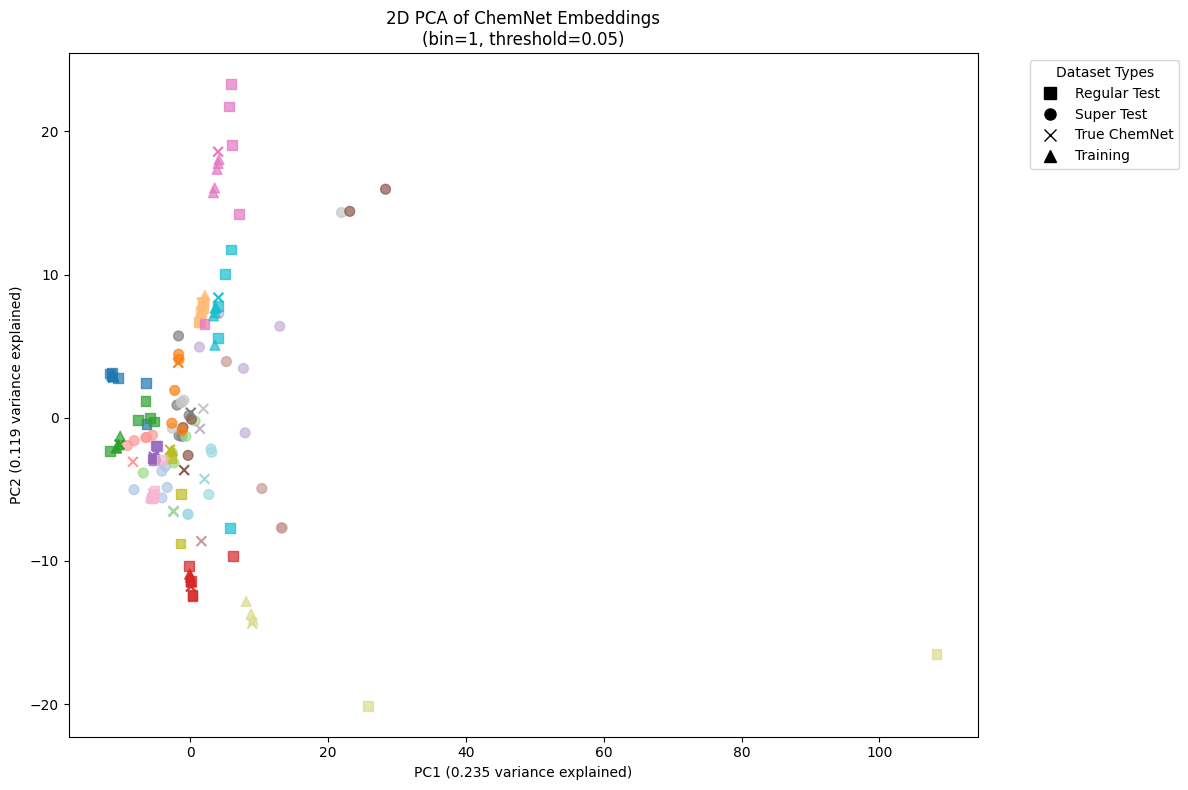

In [ ]:
plot_chemnet_pca(
    bin_val=1,                              # The bin value used for naming outputs (default: 1)
    threshold_val=0.05,                      # The threshold value for naming outputs (default: 0.1)
    include_super_test=True,                # Whether to include super test dataset (default: True)
    include_regular_test=True,              # Whether to include regular test dataset (default: True)
    include_true_chemnet=True,              # Whether to include True ChemNet embeddings (default: True)
    include_training=True,                  # Whether to include training dataset (default: True)
    color_by_smiles=True,                   # Whether to color points by SMILES (default: True)
    figsize=(12, 8),                        # Size of the figure (default: (12, 8))
    max_spectra_per_chemical=5,            # Maximum spectra per chemical plotted (default: 10)
    max_smiles_per_set=10                  # Maximum number of SMILES per dataset (default: 100)
)

## Multi PCA Plot

Loaded 103 super test samples (all SMILES)
PCA fitted on super test data. Explained variance ratio: [0.33351848 0.12135168]


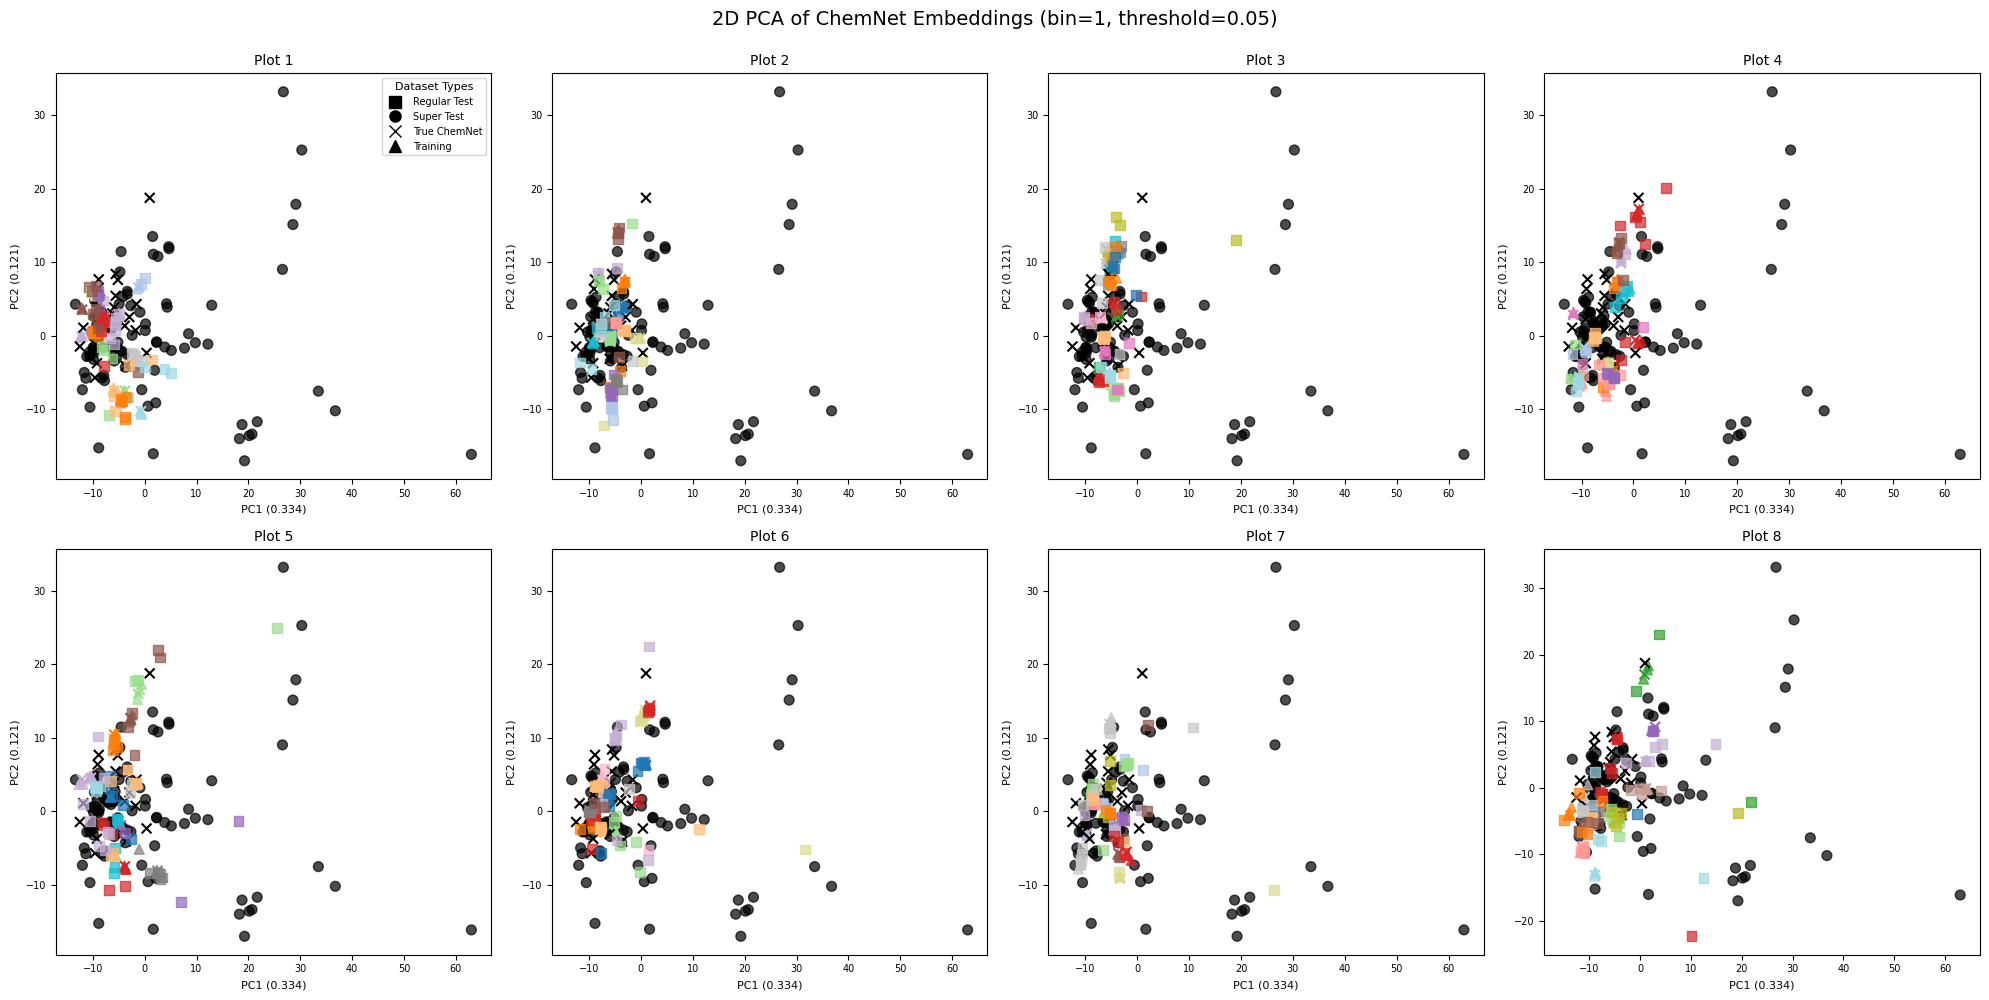

In [ ]:
# Example 4: Multi PCA Plot
plot_chemnet_pca_multi(
    bin_val=1, 
    threshold_val=0.05, 
    include_super_test=True, 
    include_regular_test=True, 
    include_true_chemnet=True, 
    include_training=True,
    color_by_smiles=True, 
    super_test_black=True,
    figsize=(20, 10), 
    max_spectra_per_chemical=5, 
    max_smiles_per_set=15,
    n_plots=8, 
    random_seed=42,
    use_new_df=True
)